In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set the style for the plots
sns.set_theme(style="whitegrid")

In [2]:
# Define paths and groups
base_path = '.' # Current directory since the notebook is in the same folder
optimizers = {'WithAdamOptimizer': 'Adam', 'WithSGDOptimizer': 'SGD'}
datasets = ['Reddit', 'Twitter']

group1_models = [
    'baseline_tcn_model_fine_tune_sb_pool_no_early_stop',
    'tcn_model_fine_tune_mb_pool',
    'tcn_model_fine_tune_mb_seqOut',
    'tcn_model_fine_tune_sb_pool',
    'tcn_model_fine_tune_sb_seqOut'
]

group2_models = [
    'baseline_tcn_model_fine_tune_sb_pool_no_early_stop',
    'tcn_model_mb_precompute_pool',
    'tcn_model_mb_precompute_seqOut',
    'tcn_model_sb_precompute_pool',
    'tcn_model_sb_precompute_seqOut'
]

all_data = []

for opt_folder, opt_name in optimizers.items():
    for dataset in datasets:
        dataset_path = os.path.join(base_path, opt_folder, dataset)
        
        # Process Group 1
        for model in group1_models:
            # Handle filename variations
            if model == 'baseline_tcn_model_fine_tune_sb_pool_no_early_stop':
                if opt_name == 'Adam':
                    filename = f"{model}_adam_{dataset}_result.csv"
                else:
                    filename = f"{model}_{dataset}_result.csv"
            else:
                filename = f"{model}_{dataset}_result.csv"
            
            file_path = os.path.join(dataset_path, filename)
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                df['Optimizer'] = opt_name
                df['Dataset'] = dataset
                df['Model Group'] = 'Fine-Tuning'
                df['Model Name'] = model
                all_data.append(df)
            else:
                print(f"File not found: {file_path}")

        # Process Group 2
        for model in group2_models:
            # Handle filename variations
            if model == 'baseline_tcn_model_fine_tune_sb_pool_no_early_stop':
                if opt_name == 'Adam':
                    filename = f"{model}_adam_{dataset}_result.csv"
                else:
                    filename = f"{model}_{dataset}_result.csv"
            else:
                filename = f"{model}_{dataset}_result.csv"

            file_path = os.path.join(dataset_path, filename)
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                df['Optimizer'] = opt_name
                df['Dataset'] = dataset
                df['Model Group'] = 'Precomputed'
                df['Model Name'] = model
                all_data.append(df)
            else:
                print(f"File not found: {file_path}")

full_df = pd.concat(all_data, ignore_index=True)

# Rename models for better readability
def clean_model_name(name):
    if name == 'tcn_model_fine_tune_sb_pool':
        return 'Baseline (AL-BTCN with ES)'
    if name == 'baseline_tcn_model_fine_tune_sb_pool_no_early_stop':
        return 'Baseline (AL-BTCN)'
    
    # Remove prefix and group identifiers
    name = name.replace('tcn_model_', '')
    name = name.replace('fine_tune_', '').replace('precompute_', '')
    
    # Replace abbreviations
    name = name.replace('mb_', 'MentalBERT ')
    name = name.replace('sb_', 'SmallBERT ')
    name = name.replace('pool', 'Pool')
    name = name.replace('seqOut', 'Seq')
    
    return name + " (ES)"

full_df['Model Name'] = full_df['Model Name'].apply(clean_model_name)

# Display the first few rows to verify
full_df.head()

,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s),Variant,Dataset,Optimizer,Model Group,Model Name
0,1,0.866509,0.866071,0.880484,0.873218,0.931307,901.022663,baseline_tcn_model_fine_tune_sb_pool_no_early_...,Reddit,Adam,Fine-Tuning,Baseline (AL-BTCN)
1,2,0.861715,0.863772,0.872920,0.868322,0.916950,894.637512,baseline_tcn_model_fine_tune_sb_pool_no_early_...,Reddit,Adam,Fine-Tuning,Baseline (AL-BTCN)
2,3,0.877124,0.865510,0.905446,0.885028,0.910361,892.367417,baseline_tcn_model_fine_tune_sb_pool_no_early_...,Reddit,Adam,Fine-Tuning,Baseline (AL-BTCN)
3,4,0.860529,0.834831,0.913767,0.872517,0.937092,896.122092,baseline_tcn_model_fine_tune_sb_pool_no_early_...,Reddit,Adam,Fine-Tuning,Baseline (AL-BTCN)
4,5,0.870407,0.857451,0.901590,0.878967,0.937885,892.411189,baseline_tcn_model_fine_tune_sb_pool_no_early_...,Reddit,Adam,Fine-Tuning,Baseline (AL-BTCN)


Group 1: Fine-Tuning Models Analysis


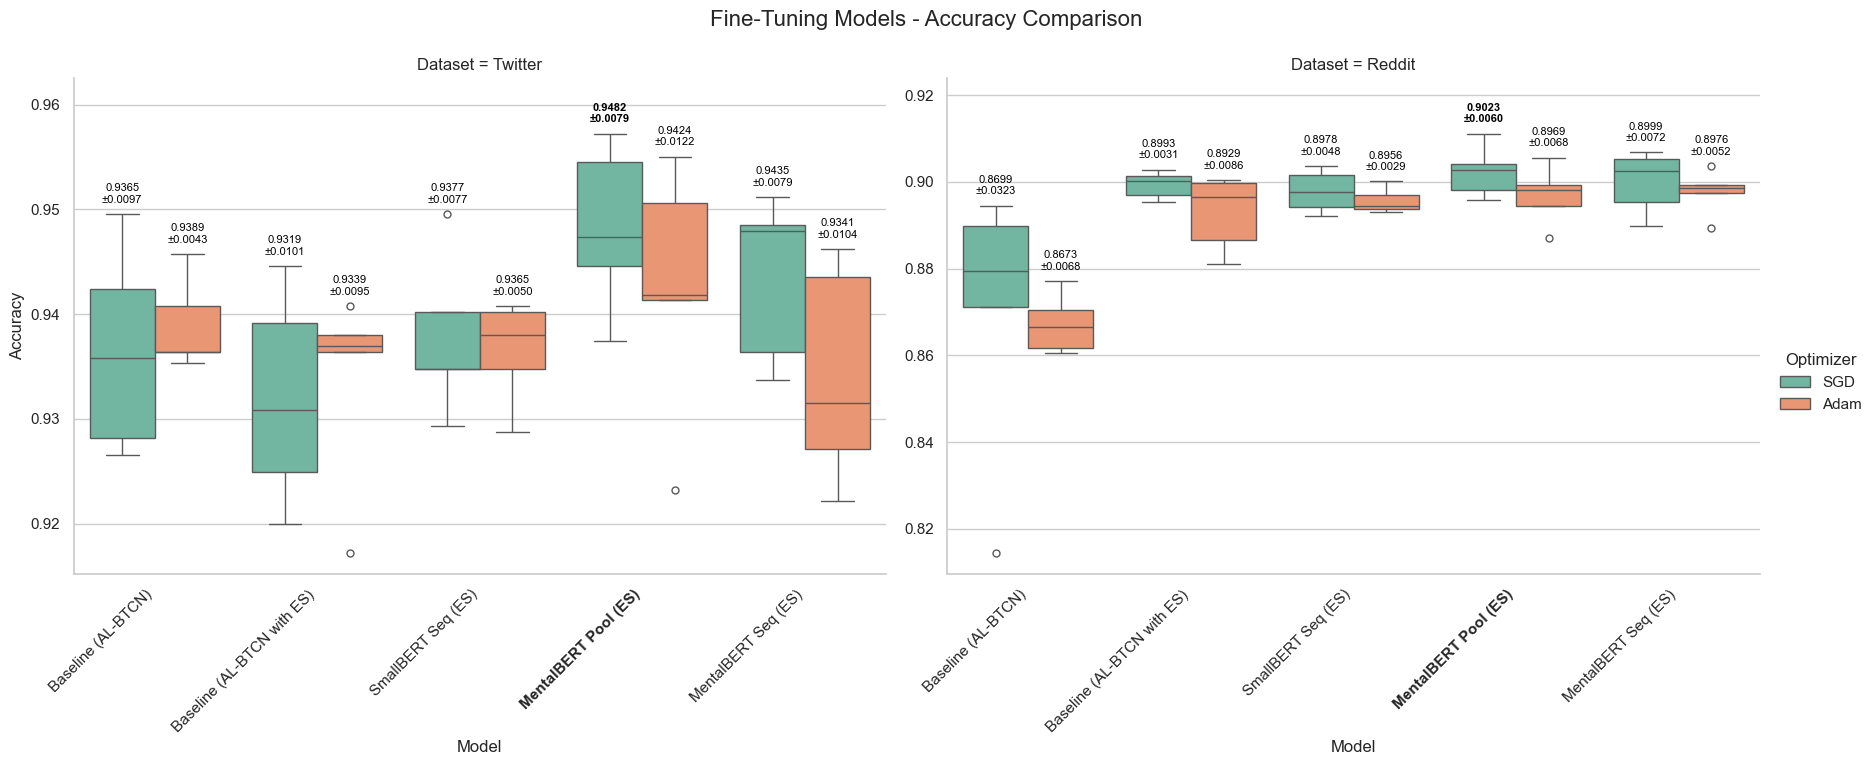

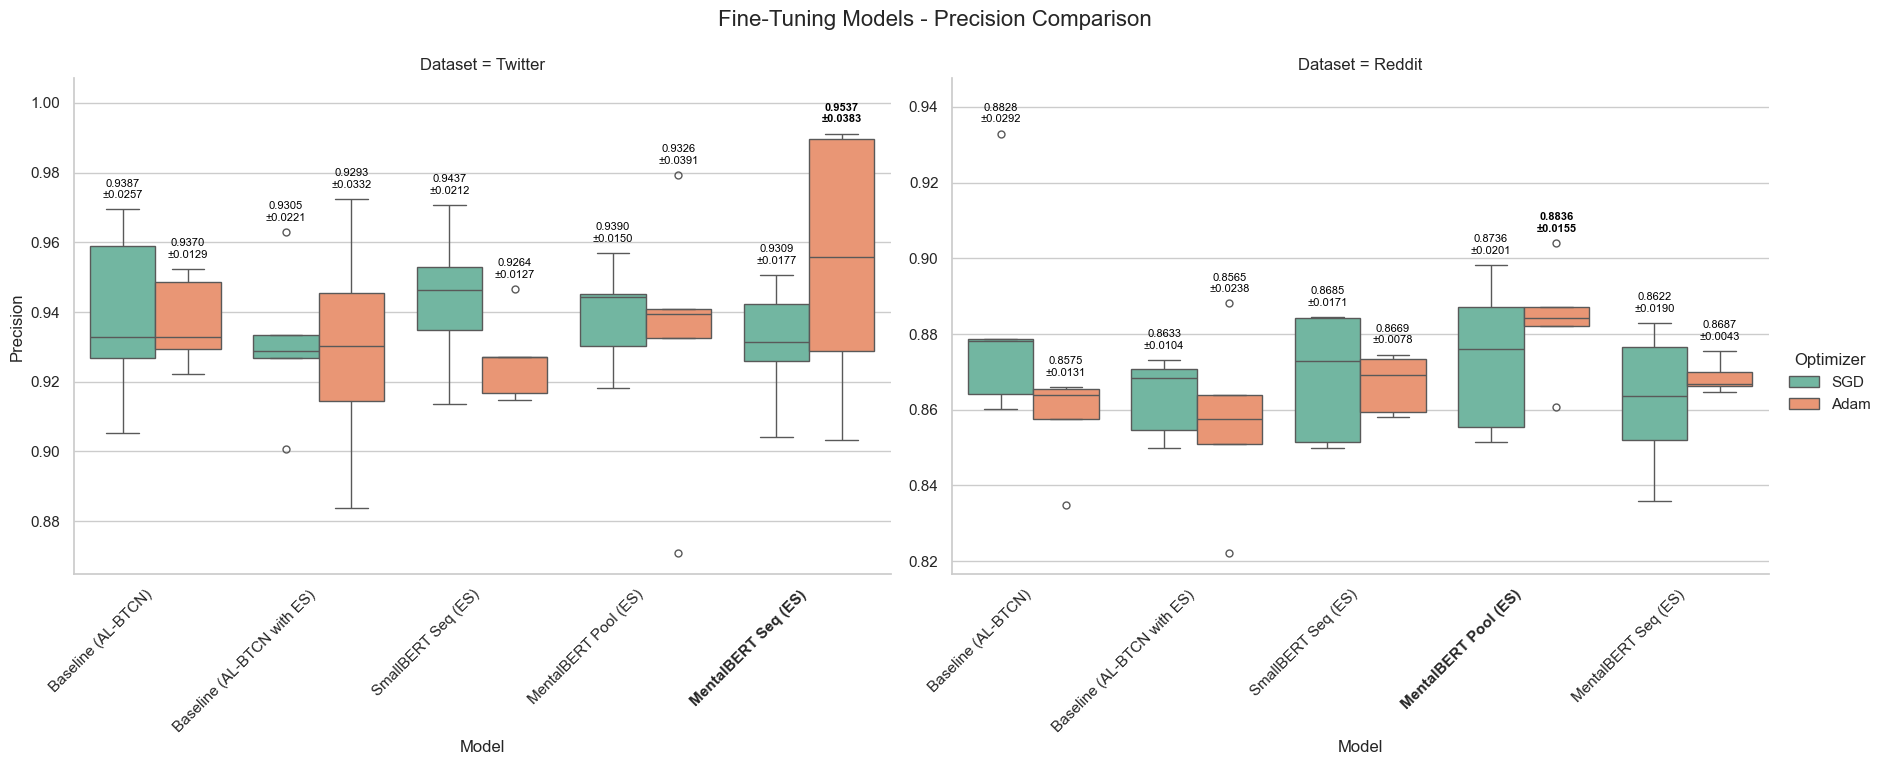

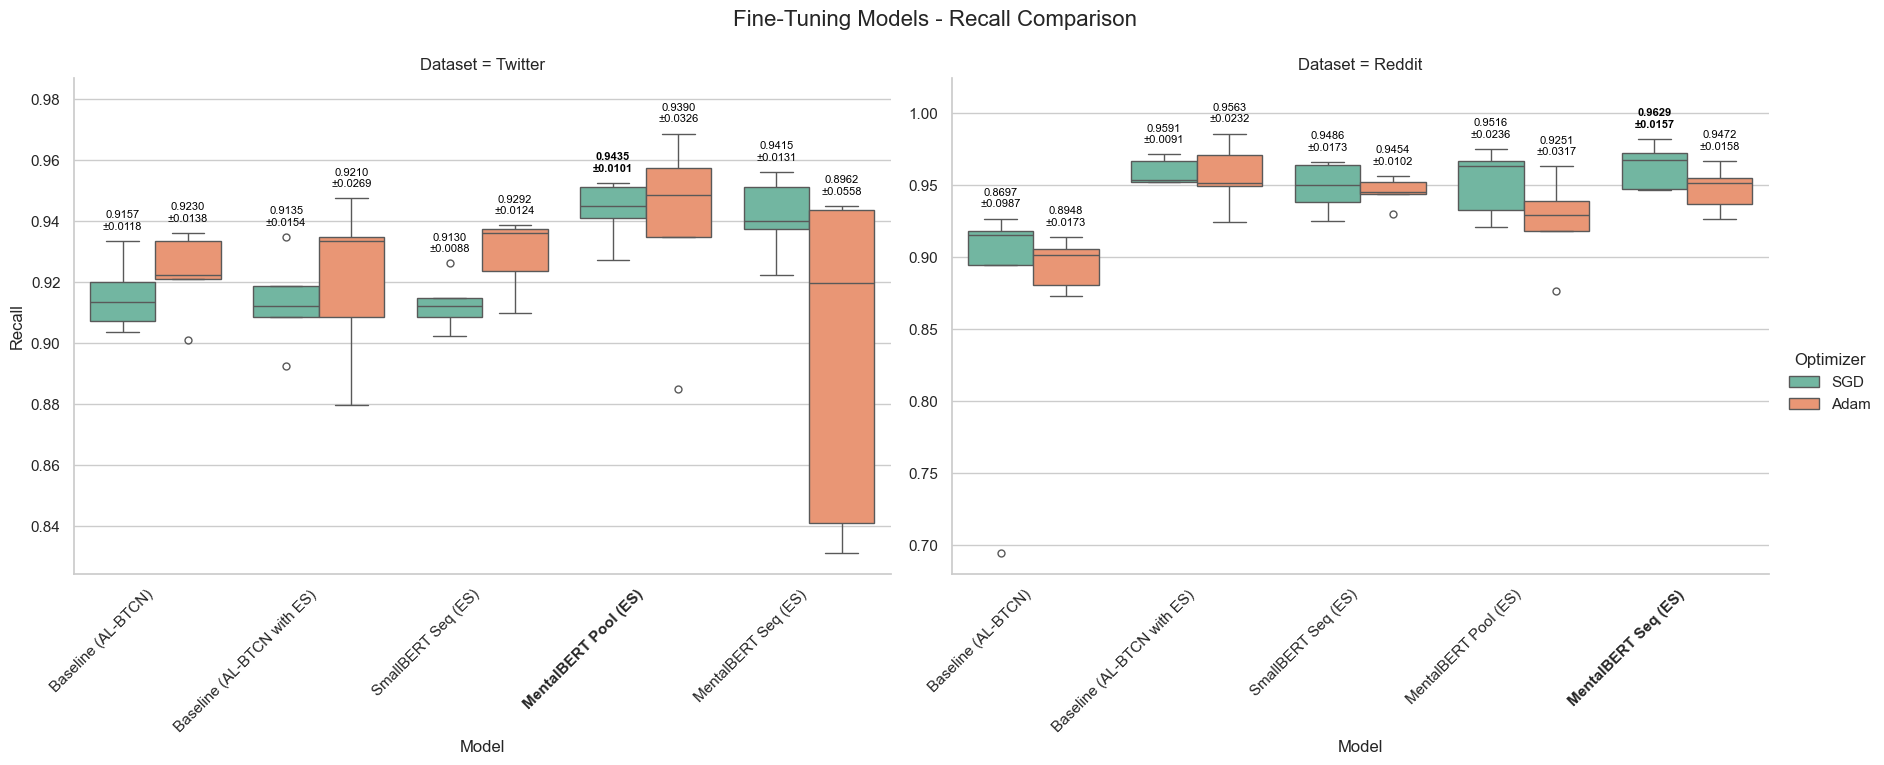

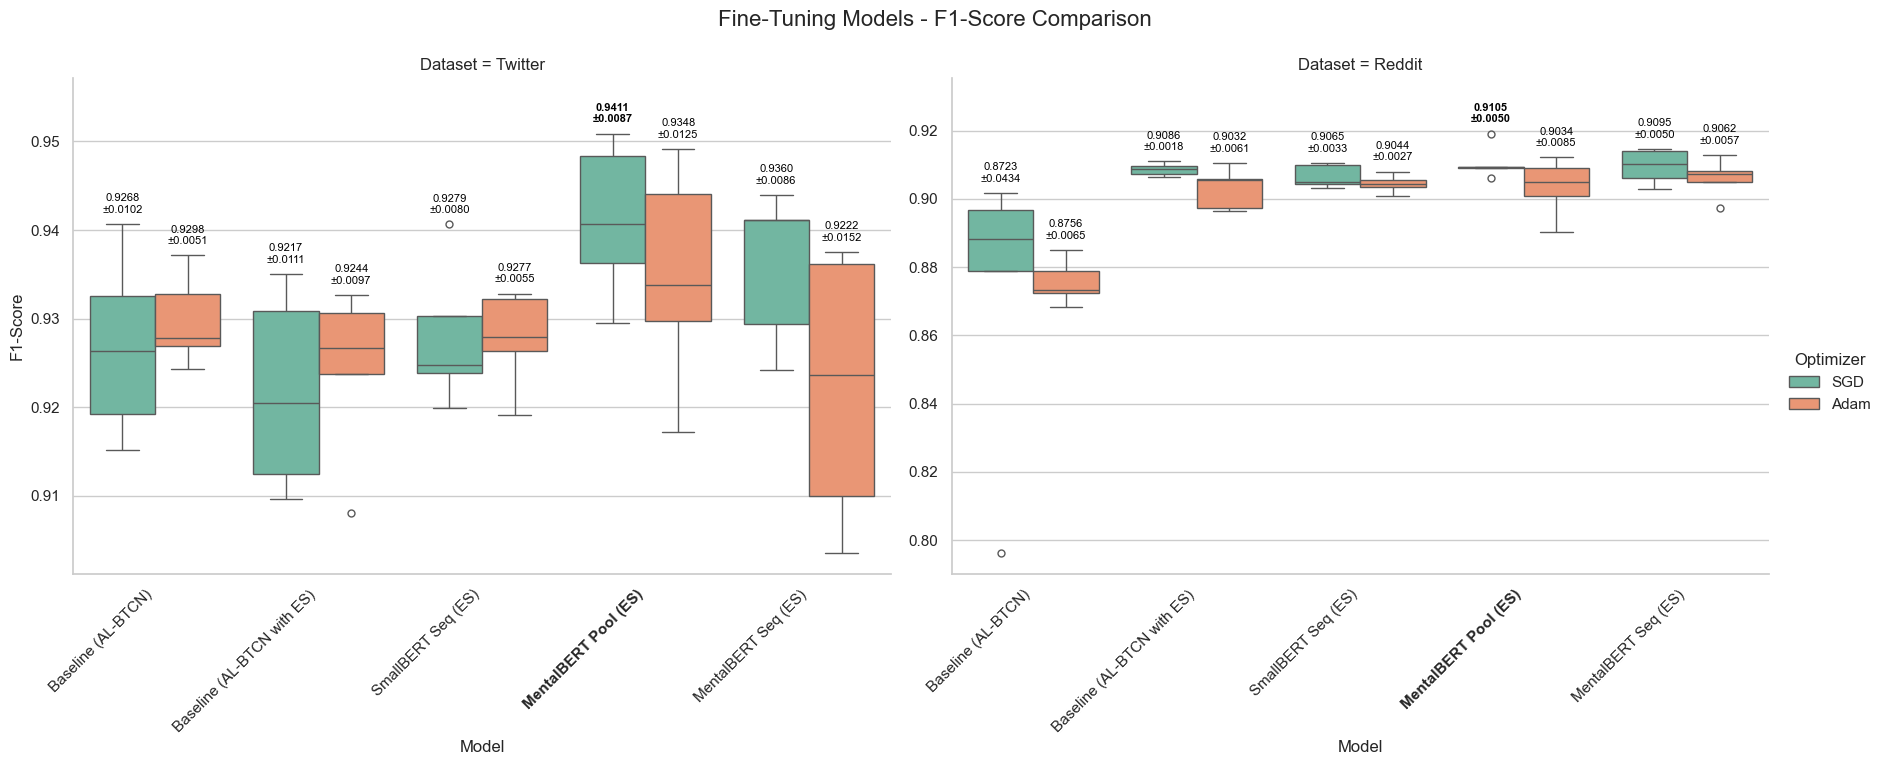

Group 2: Precomputed Models Analysis


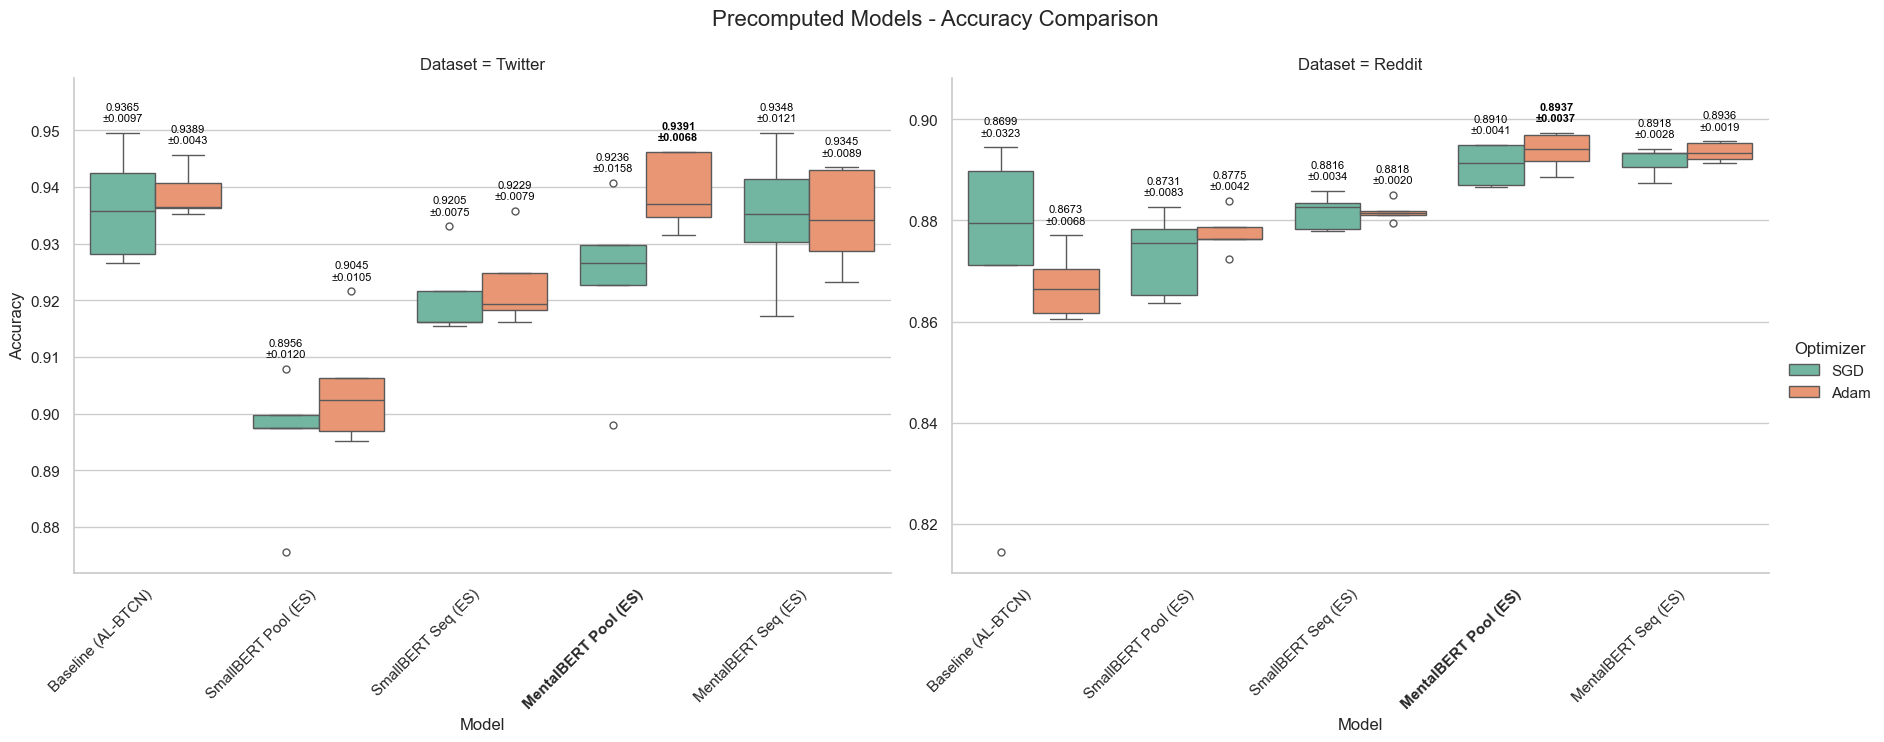

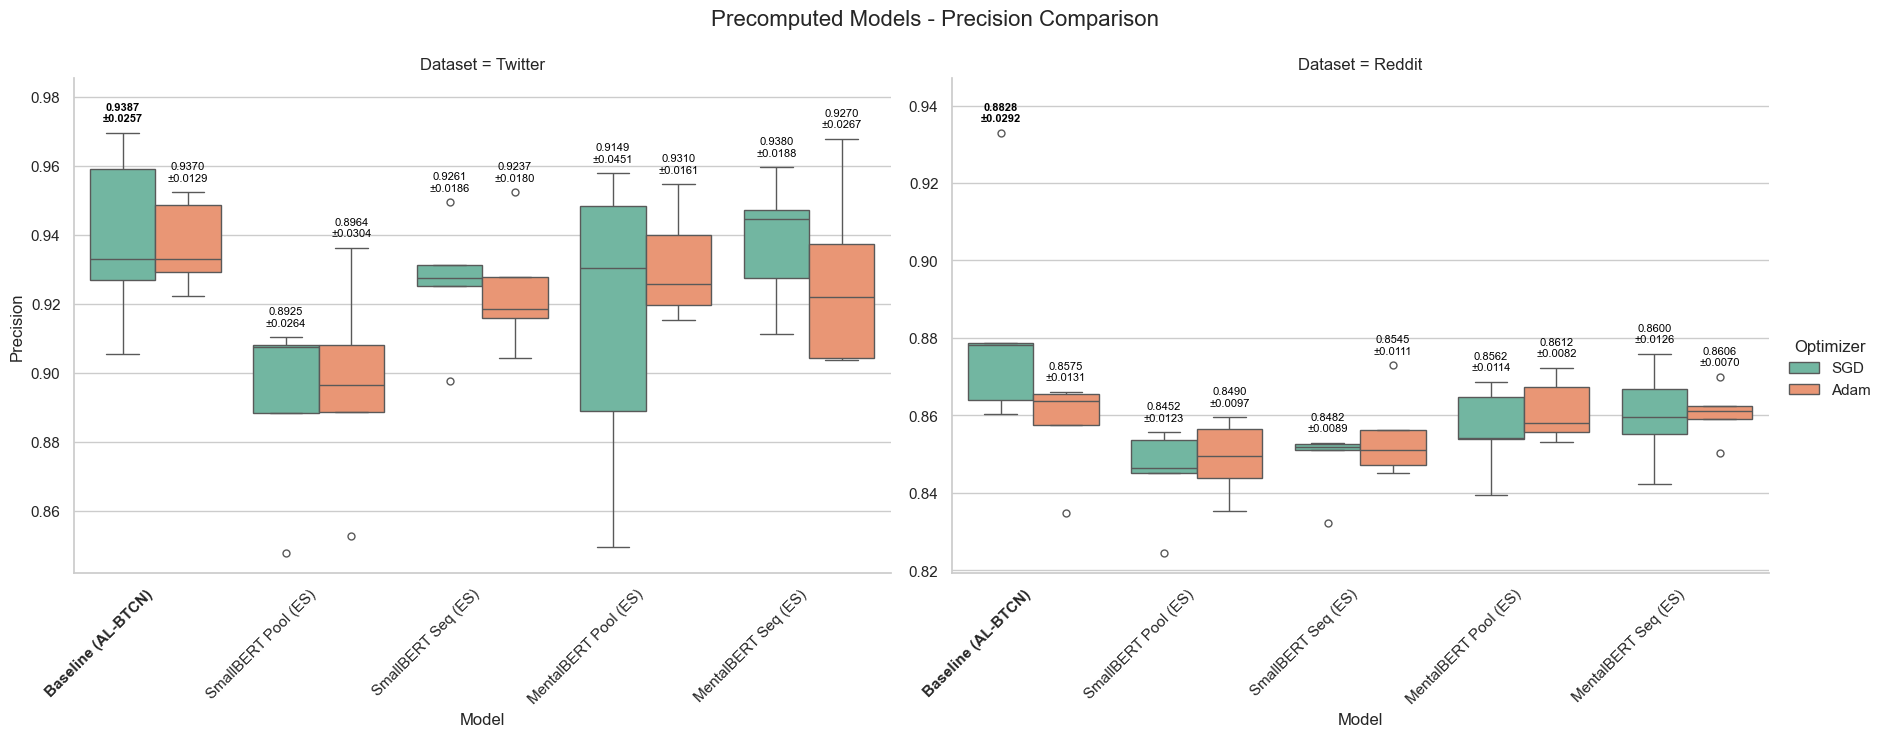

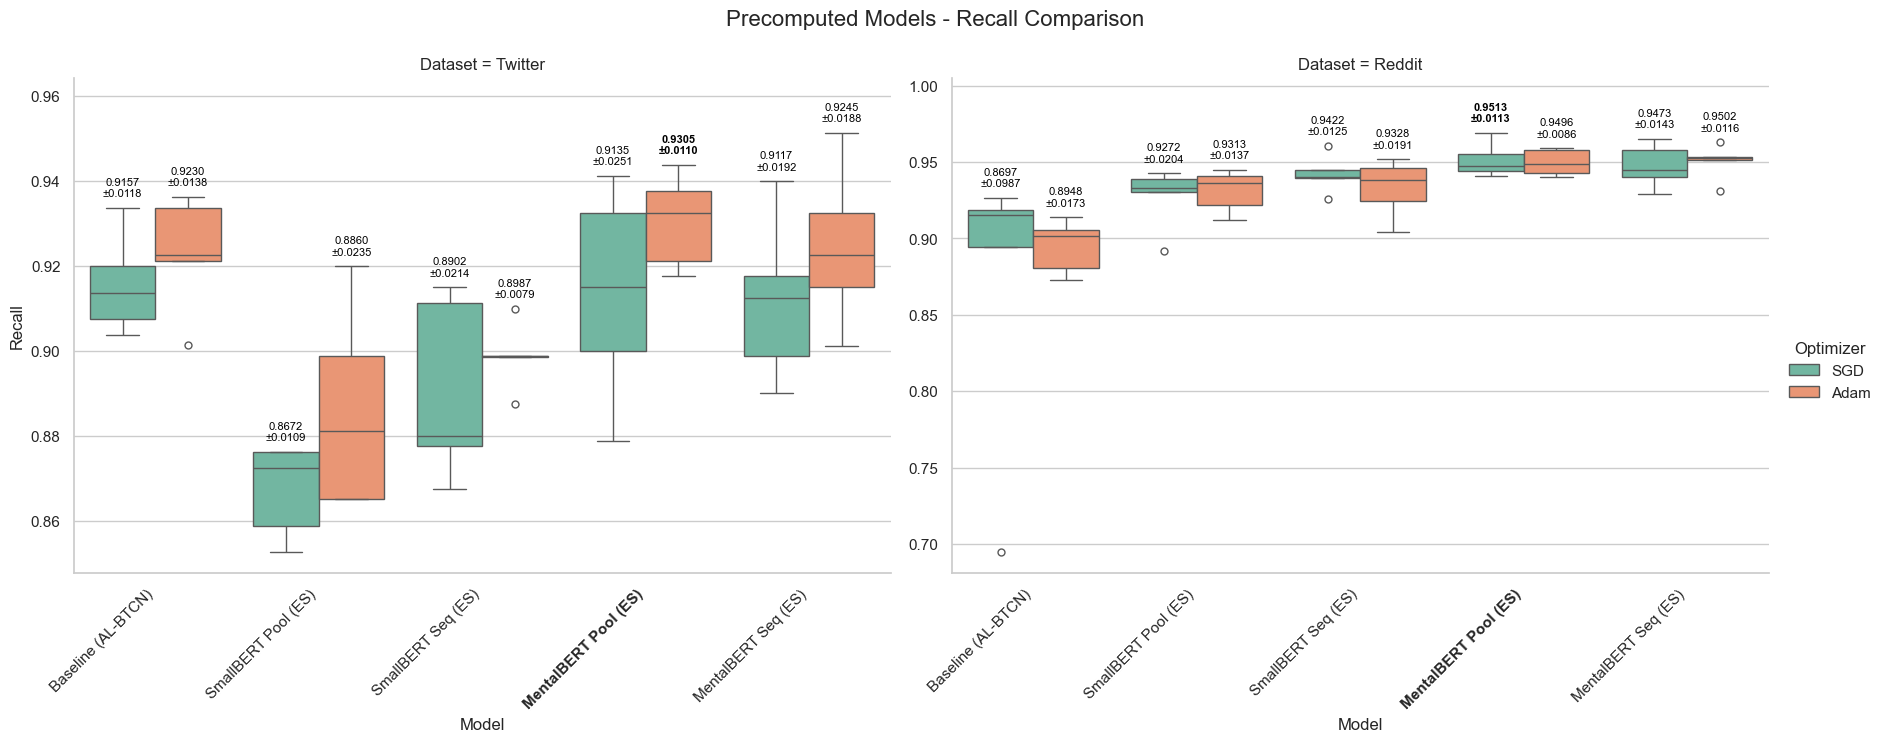

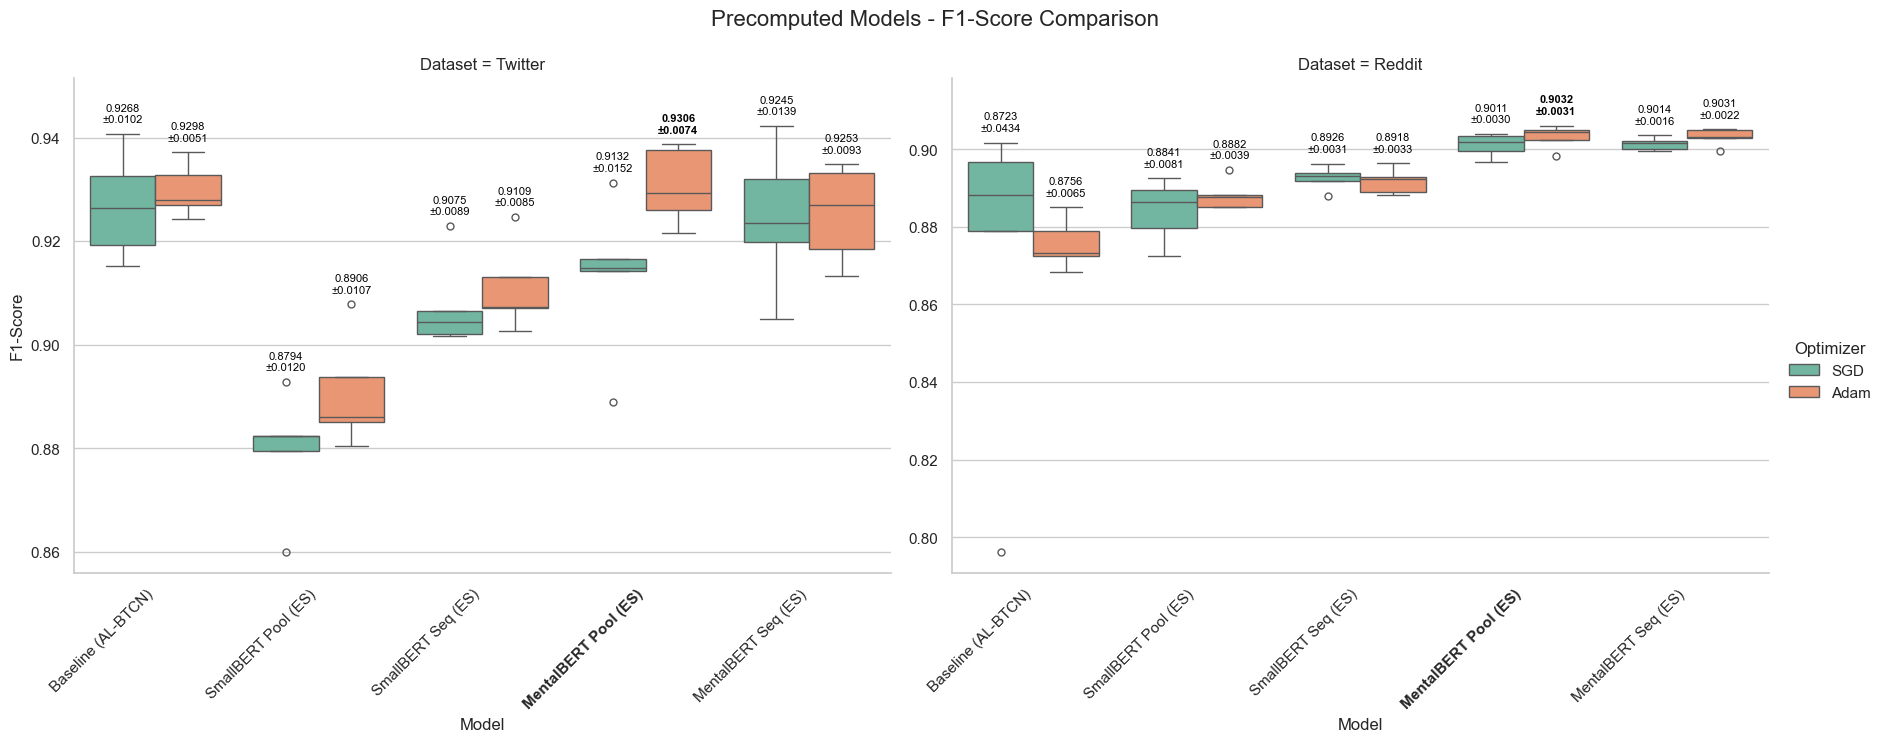

In [3]:
def plot_comparison(df, group_name, metric='Accuracy', order=None):
    """
    Plots a boxplot comparison for a given group of models and metric.
    """
    # Define custom palette to switch colors (swapping the first two colors of Set2)
    palette = {
        'Adam': sns.color_palette("Set2")[1],
        'SGD': sns.color_palette("Set2")[0]
    }
    
    hue_order = ['SGD', 'Adam']
    col_order = ['Twitter', 'Reddit'] # Changed order: Twitter first, then Reddit
    
    g = sns.catplot(
        data=df, 
        kind="box",
        x="Model Name", 
        y=metric, 
        hue="Optimizer",
        hue_order=hue_order, # Explicitly set order: SGD first, then Adam
        col="Dataset",
        col_order=col_order,
        height=6, 
        aspect=1.5,
        palette=palette,
        sharey=False, # Allow y-axis to vary between datasets if needed, or set to True for comparison
        order=order
    )
    g.fig.suptitle(f'{group_name} - {metric} Comparison', y=1.05, fontsize=16)
    g.set_xticklabels(rotation=45, ha='right')
    g.set_axis_labels("Model", metric)
    
    # Add mean and std annotations
    for ax, dataset_name in zip(g.axes.flat, col_order):
        # Filter data for the current dataset
        dataset_df = df[df['Dataset'] == dataset_name]
        
        # Find the highest mean value for this dataset
        best_mean = -1
        best_model = None
        best_optimizer = None
        
        # First pass: find the best model/optimizer
        for model_name in order:
            for optimizer in hue_order:
                subset = dataset_df[(dataset_df['Model Name'] == model_name) & (dataset_df['Optimizer'] == optimizer)]
                if not subset.empty:
                    mean_val = subset[metric].mean()
                    if mean_val > best_mean:
                        best_mean = mean_val
                        best_model = model_name
                        best_optimizer = optimizer

        # Calculate width of each hue bar
        # Default width in seaborn boxplot is 0.8 for the whole group
        width = 0.8
        n_hues = len(hue_order)
        
        # Get current y-limits to adjust if necessary
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        
        for i, model_name in enumerate(order):
            for j, optimizer in enumerate(hue_order):
                subset = dataset_df[(dataset_df['Model Name'] == model_name) & (dataset_df['Optimizer'] == optimizer)]
                if not subset.empty:
                    mean_val = subset[metric].mean()
                    std_val = subset[metric].std()
                    
                    # Calculate x position
                    # The center of the group is at i
                    # The offsets are calculated to center the bars around i
                    # Formula: i + (j - (n_hues - 1) / 2) * (width / n_hues)
                    x_pos = i + (j - (n_hues - 1) / 2) * (width / n_hues)
                    
                    # Calculate y position (above the max value of the data to avoid overlap)
                    # Use max value of the specific box
                    val_max = subset[metric].max()
                    
                    # Add text
                    text = f"{mean_val:.4f}\n±{std_val:.4f}"
                    
                    # Determine font weight
                    is_best = (model_name == best_model) and (optimizer == best_optimizer)
                    font_weight = 'bold' if is_best else 'normal'
                    
                    # Offset for text
                    offset = y_range * 0.02
                    
                    ax.text(
                        x_pos, 
                        val_max + offset, 
                        text, 
                        ha='center', 
                        va='bottom', 
                        fontsize=8, 
                        color='black',
                        fontweight=font_weight
                    )
                    
                    # Update y_max if text goes out of bounds (approximate check)
                    # This is a simple heuristic
                    if val_max + offset + (y_range * 0.05) > y_max:
                        y_max = val_max + offset + (y_range * 0.1)
        
        # Bold the x-axis label for the best model
        xticklabels = ax.get_xticklabels()
        for label in xticklabels:
            if label.get_text() == best_model:
                label.set_fontweight('bold')
        
        # Apply new y-limit
        ax.set_ylim(y_min, y_max)

    plt.show()

# Filter data for each group
df_group1 = full_df[full_df['Model Group'] == 'Fine-Tuning']
df_group2 = full_df[full_df['Model Group'] == 'Precomputed']

# Define order for Group 1
group1_order = [
    'Baseline (AL-BTCN)',
    'Baseline (AL-BTCN with ES)',
    'SmallBERT Seq (ES)',
    'MentalBERT Pool (ES)',
    'MentalBERT Seq (ES)'
]

# Define order for Group 2 (Logical ordering)
group2_order = [
    'Baseline (AL-BTCN)',
    'SmallBERT Pool (ES)',
    'SmallBERT Seq (ES)',
    'MentalBERT Pool (ES)',
    'MentalBERT Seq (ES)'
]

# Plot for Group 1 (Fine-Tuning)
print("Group 1: Fine-Tuning Models Analysis")
plot_comparison(df_group1, "Fine-Tuning Models", 'Accuracy', order=group1_order)
plot_comparison(df_group1, "Fine-Tuning Models", 'Precision', order=group1_order)
plot_comparison(df_group1, "Fine-Tuning Models", 'Recall', order=group1_order)
plot_comparison(df_group1, "Fine-Tuning Models", 'F1-Score', order=group1_order)

# Plot for Group 2 (Precomputed)
print("Group 2: Precomputed Models Analysis")
plot_comparison(df_group2, "Precomputed Models", 'Accuracy', order=group2_order)
plot_comparison(df_group2, "Precomputed Models", 'Precision', order=group2_order)
plot_comparison(df_group2, "Precomputed Models", 'Recall', order=group2_order)
plot_comparison(df_group2, "Precomputed Models", 'F1-Score', order=group2_order)

In [4]:
# Summary Statistics Table
summary_stats = full_df.groupby(['Model Group', 'Model Name', 'Dataset', 'Optimizer'])[['Accuracy', 'Precision', 'Recall', 'F1-Score']].agg(['mean', 'std']).round(4)
print("Summary Statistics (Mean and Std Dev):")
display(summary_stats)

Summary Statistics (Mean and Std Dev):


Accuracy          \
                                                             mean     std   
Model Group Model Name                 Dataset Optimizer                    
Fine-Tuning Baseline (AL-BTCN with ES) Reddit  Adam        0.8929  0.0086   
                                               SGD         0.8993  0.0031   
                                       Twitter Adam        0.9339  0.0095   
                                               SGD         0.9319  0.0101   
            Baseline (AL-BTCN)         Reddit  Adam        0.8673  0.0068   
                                               SGD         0.8699  0.0323   
                                       Twitter Adam        0.9389  0.0043   
                                               SGD         0.9365  0.0097   
            MentalBERT Pool (ES)       Reddit  Adam        0.8969  0.0068   
                                               SGD         0.9023  0.0060   
                                       Twitter Adam        0.9424  0.0122   
                                               SGD         0.9482  0.0079   
            MentalBERT Seq (ES)        Reddit  Adam        0.8976  0.0052   
                                               SGD         0.8999  0.0072   
                                       Twitter Adam        0.9341  0.0104   
                                               SGD         0.9435  0.0079   
            SmallBERT Seq (ES)         Reddit  Adam        0.8956  0.0029   
                                               SGD         0.8978  0.0048   
                                       Twitter Adam        0.9365  0.0050   
                                               SGD         0.9377  0.0077   
Precomputed Baseline (AL-BTCN)         Reddit  Adam        0.8673  0.0068   
                                               SGD         0.8699  0.0323   
                                       Twitter Adam        0.9389  0.0043   
                                               SGD         0.9365  0.0097   
            MentalBERT Pool (ES)       Reddit  Adam        0.8937  0.0037   
                                               SGD         0.8910  0.0041   
                                       Twitter Adam        0.9391  0.0068   
                                               SGD         0.9236  0.0158   
            MentalBERT Seq (ES)        Reddit  Adam        0.8936  0.0019   
                                               SGD         0.8918  0.0028   
                                       Twitter Adam        0.9345  0.0089   
                                               SGD         0.9348  0.0121   
            SmallBERT Pool (ES)        Reddit  Adam        0.8775  0.0042   
                                               SGD         0.8731  0.0083   
                                       Twitter Adam        0.9045  0.0105   
                                               SGD         0.8956  0.0120   
            SmallBERT Seq (ES)         Reddit  Adam        0.8818  0.0020   
                                               SGD         0.8816  0.0034   
                                       Twitter Adam        0.9229  0.0079   
                                               SGD         0.9205  0.0075   

                                                         Precision          \
                                                              mean     std   
Model Group Model Name                 Dataset Optimizer                     
Fine-Tuning Baseline (AL-BTCN with ES) Reddit  Adam         0.8565  0.0238   
                                               SGD          0.8633  0.0104   
                                       Twitter Adam         0.9293  0.0332   
                                               SGD          0.9305  0.0221   
            Baseline (AL-BTCN)         Reddit  Adam         0.8575  0.0131   
                                               SGD          0.8828  0.0292   
                                       Twit

--- Accuracy ---
Group 1: Fine-Tuning Models - Accuracy


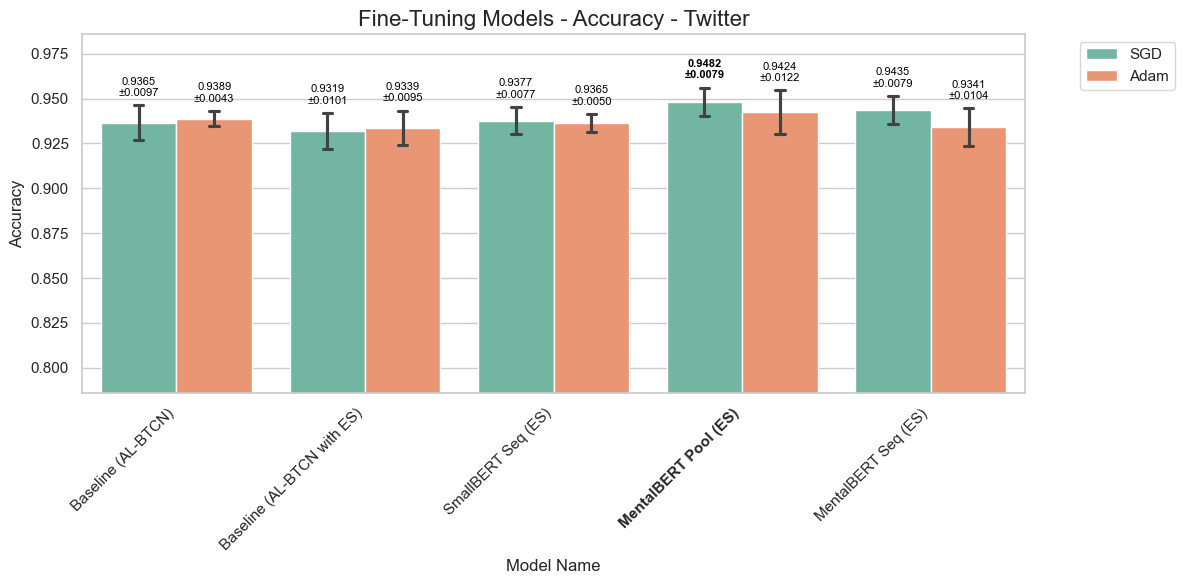

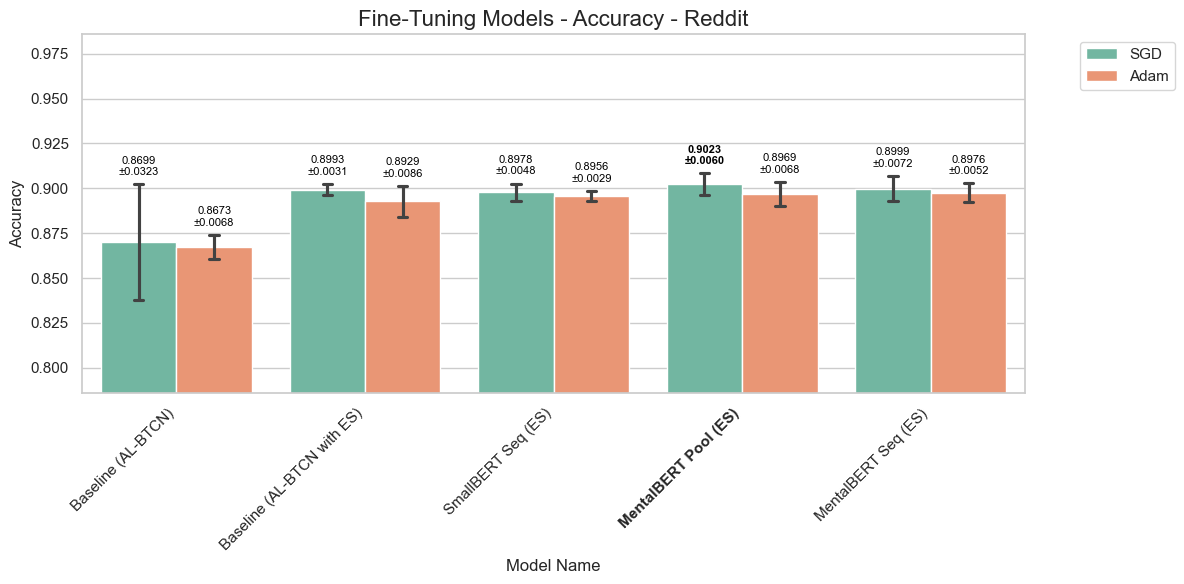

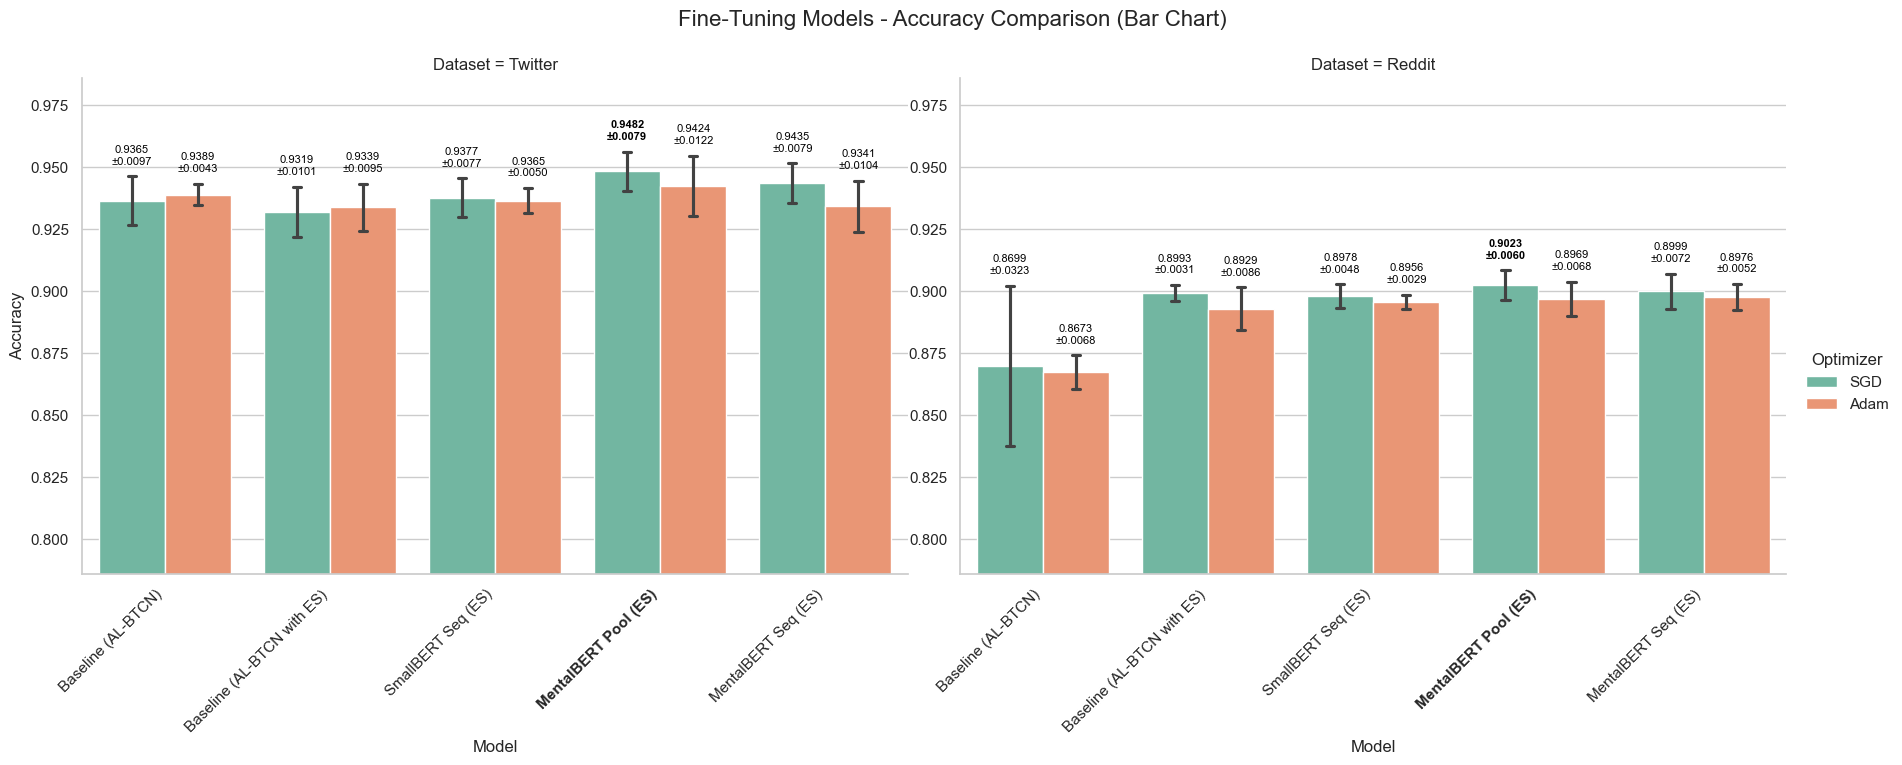

Group 2: Precomputed Models - Accuracy


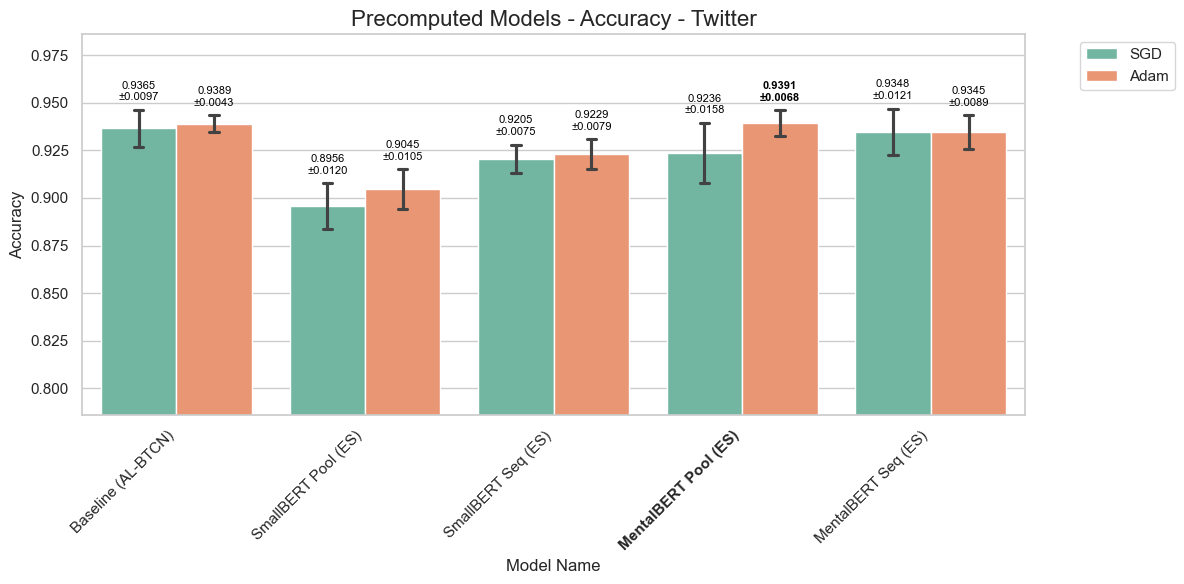

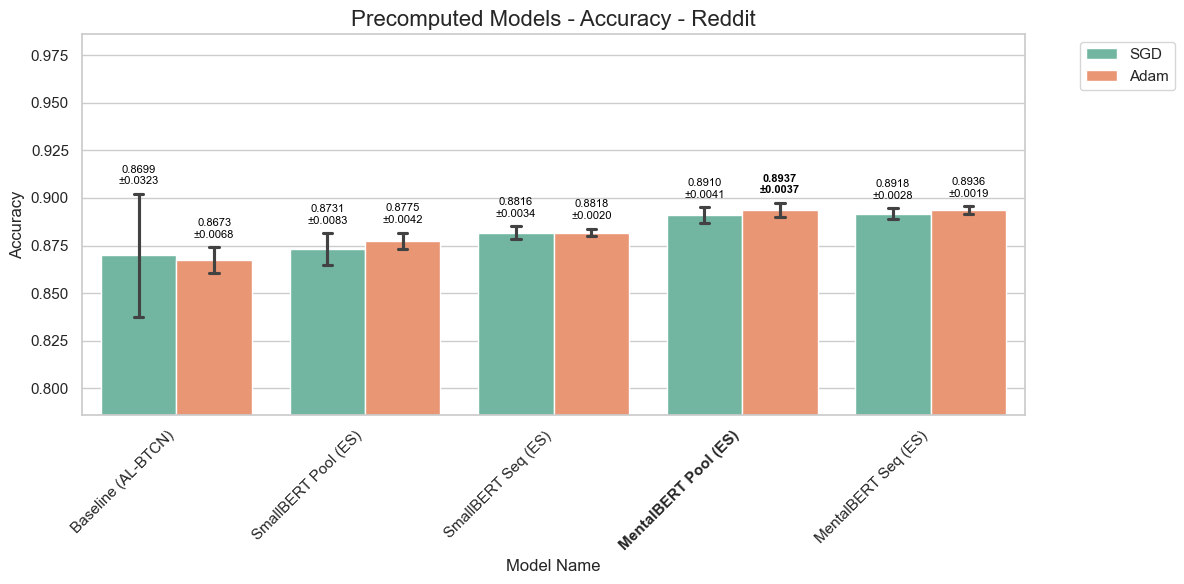

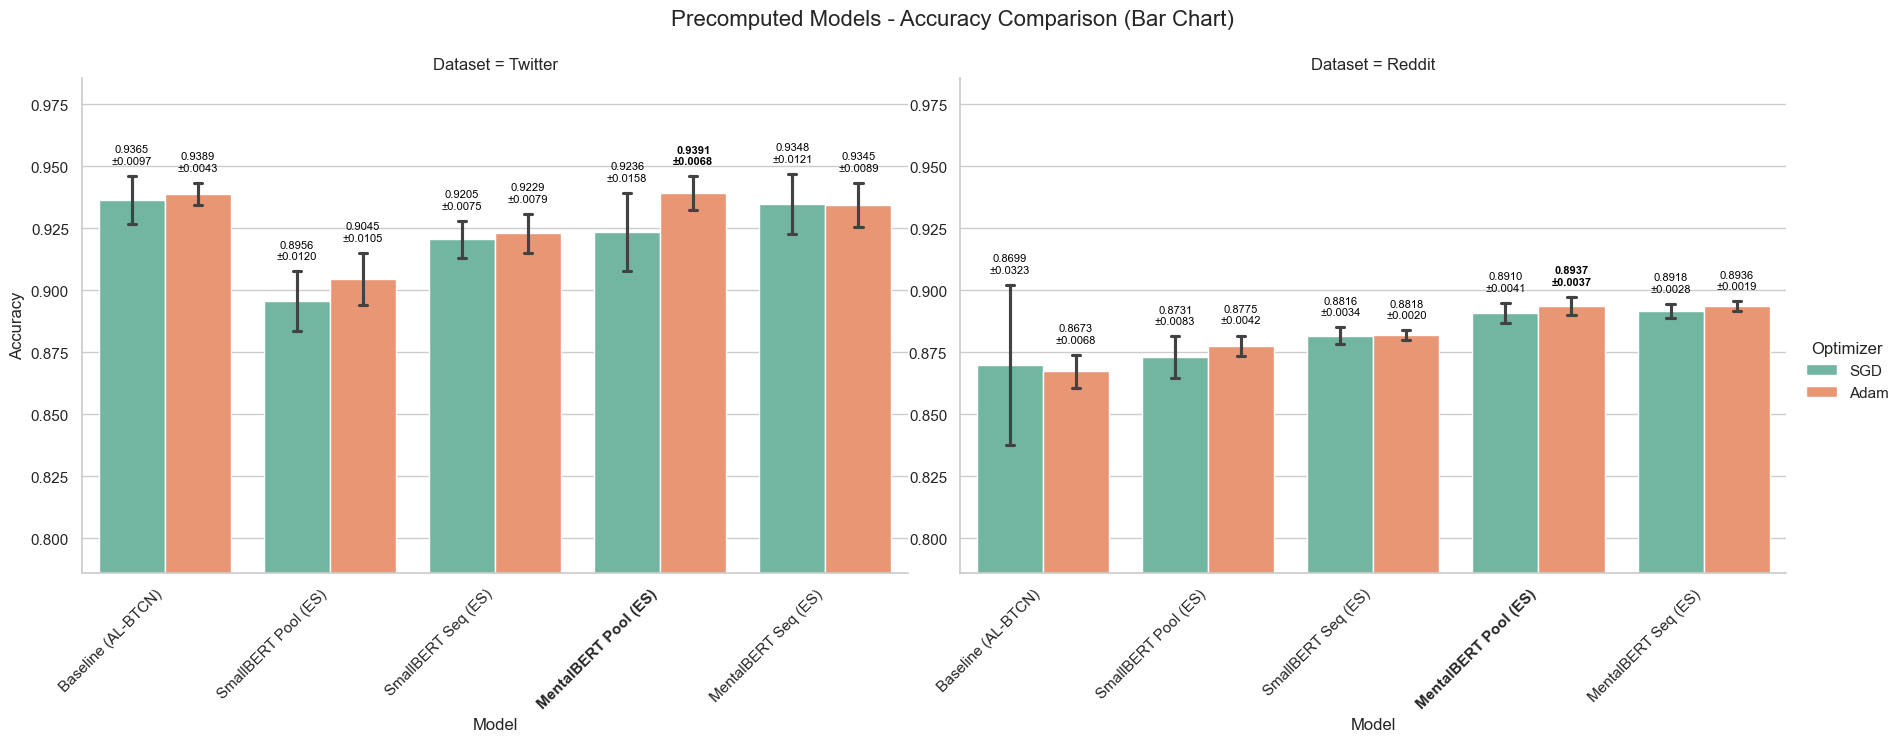

--- Precision ---
Group 1: Fine-Tuning Models - Precision


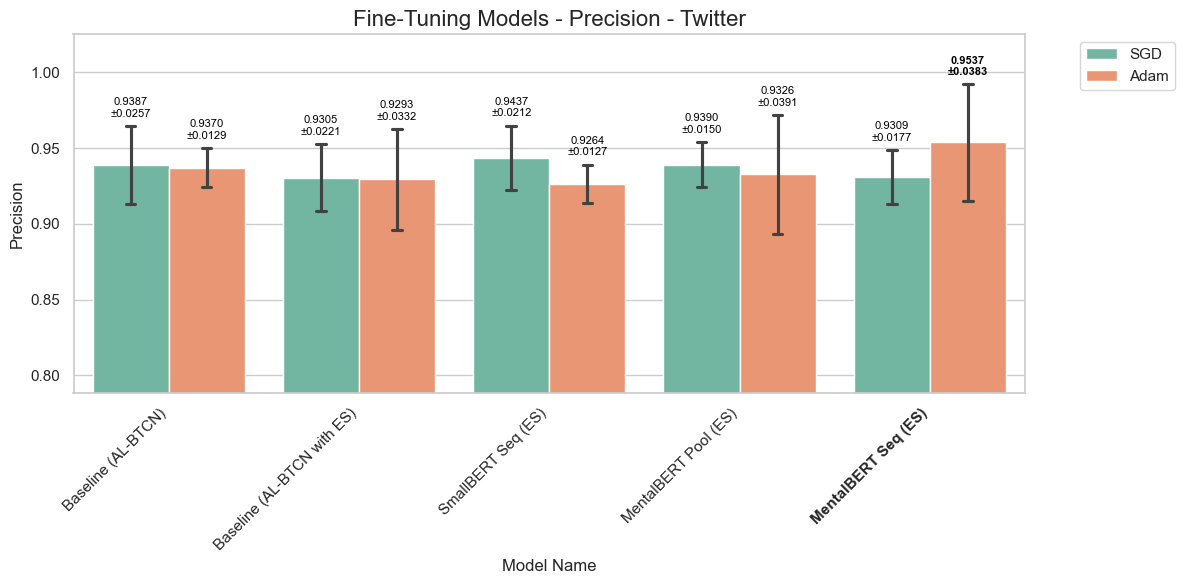

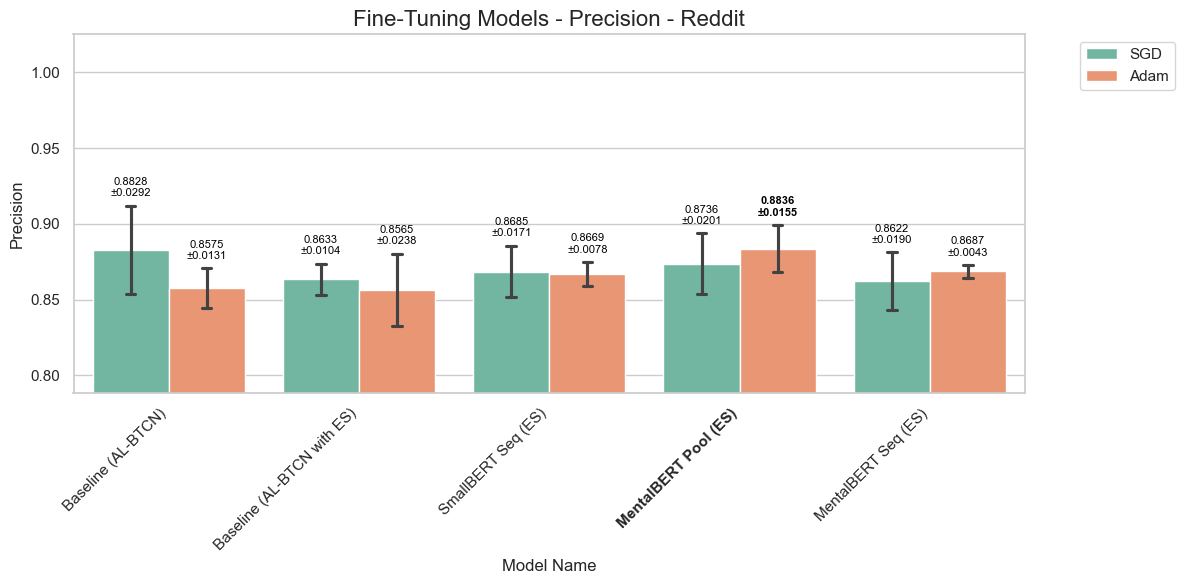

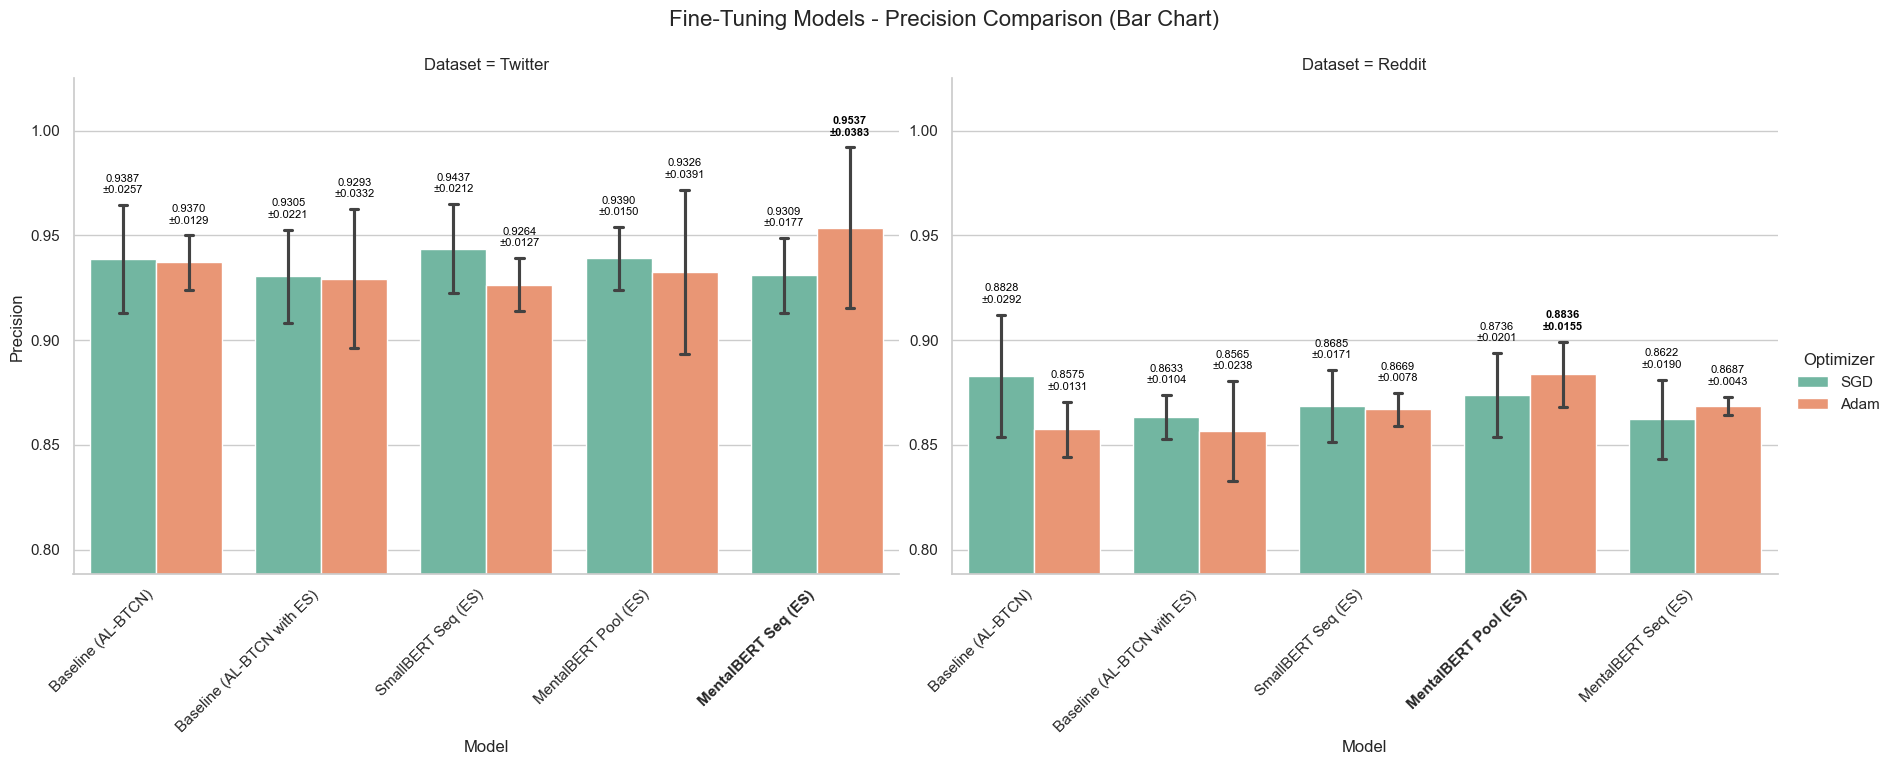

Group 2: Precomputed Models - Precision


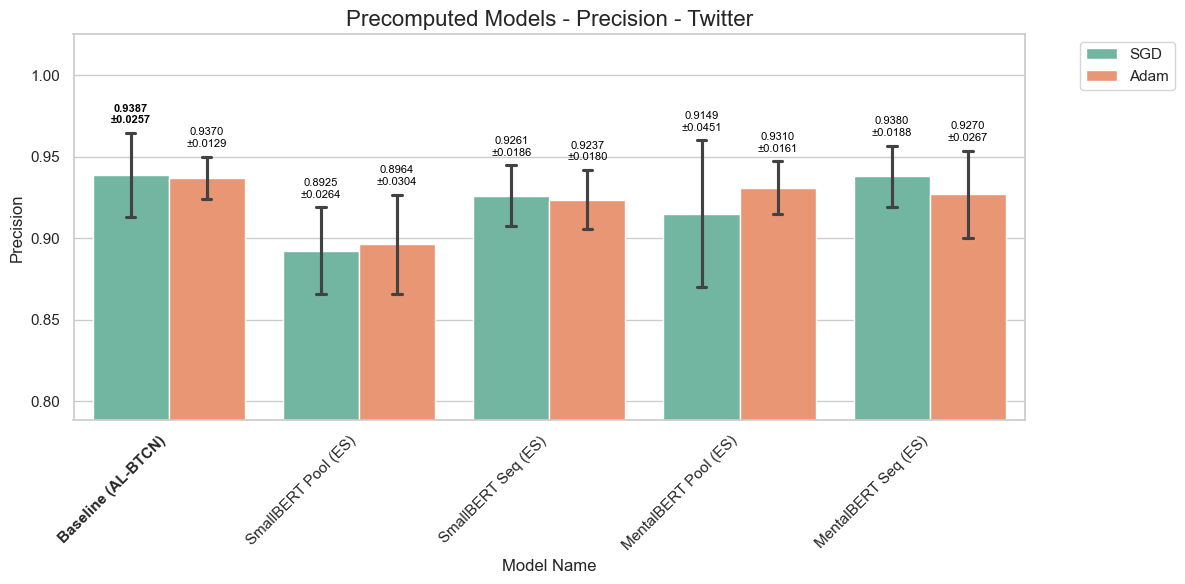

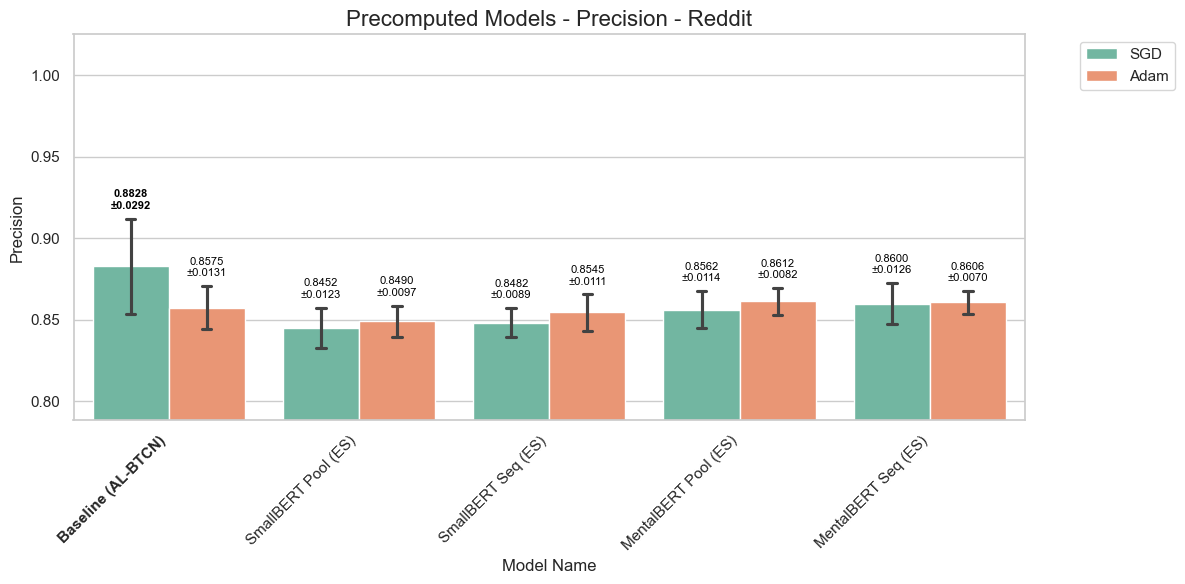

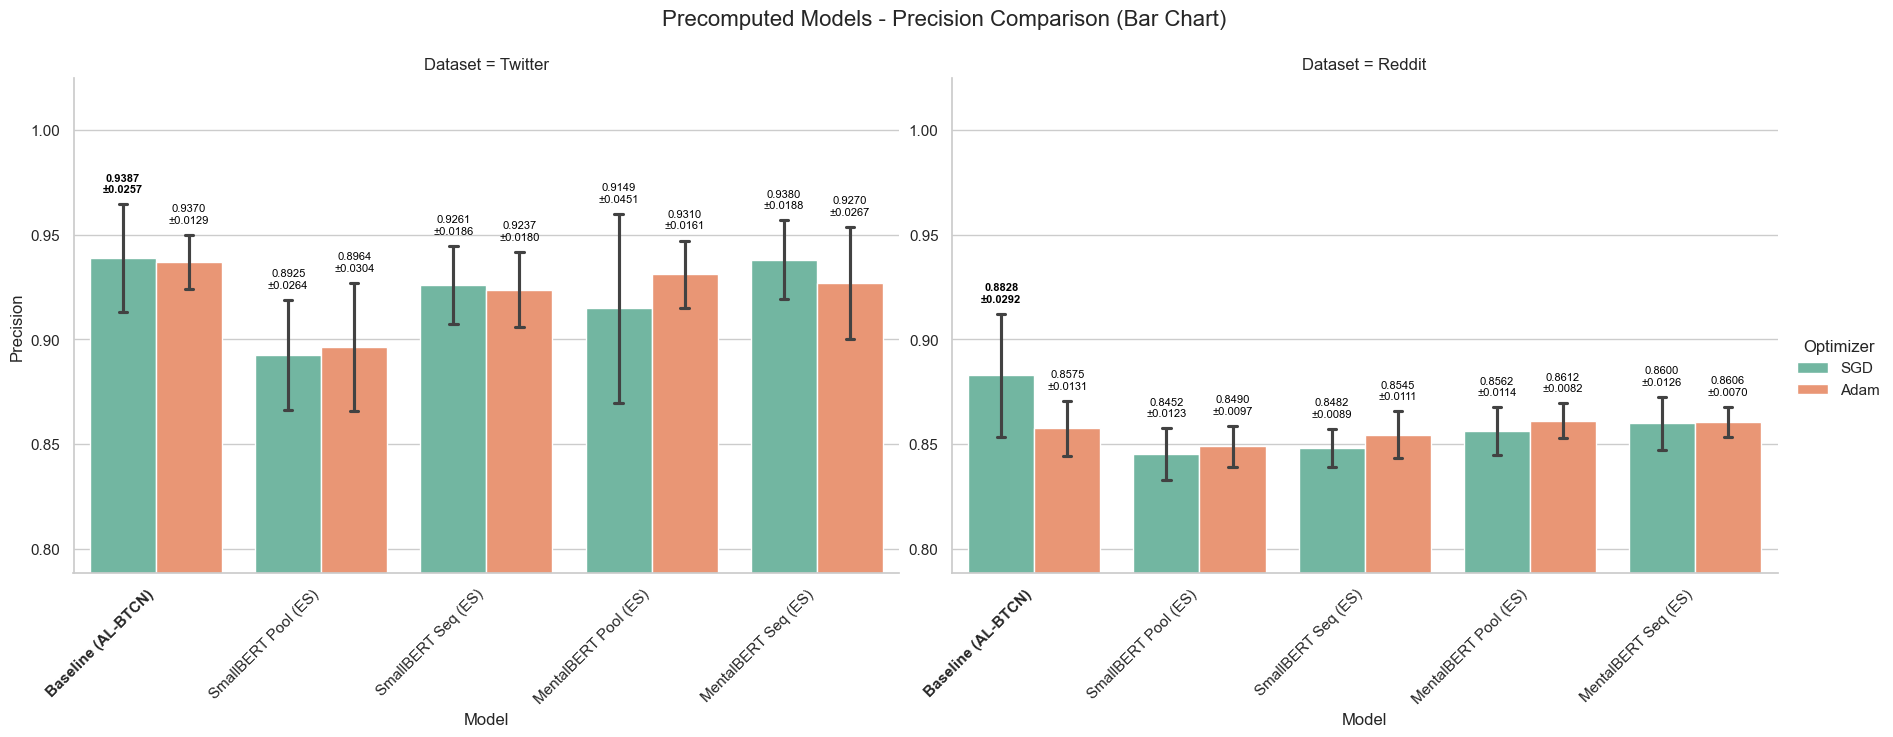

--- Recall ---
Group 1: Fine-Tuning Models - Recall


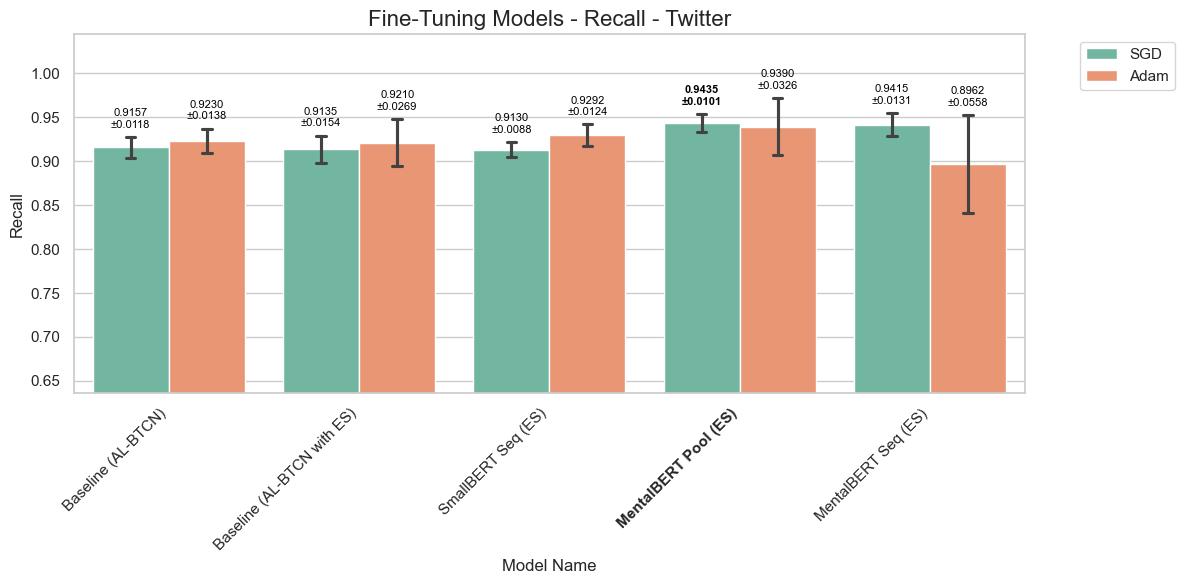

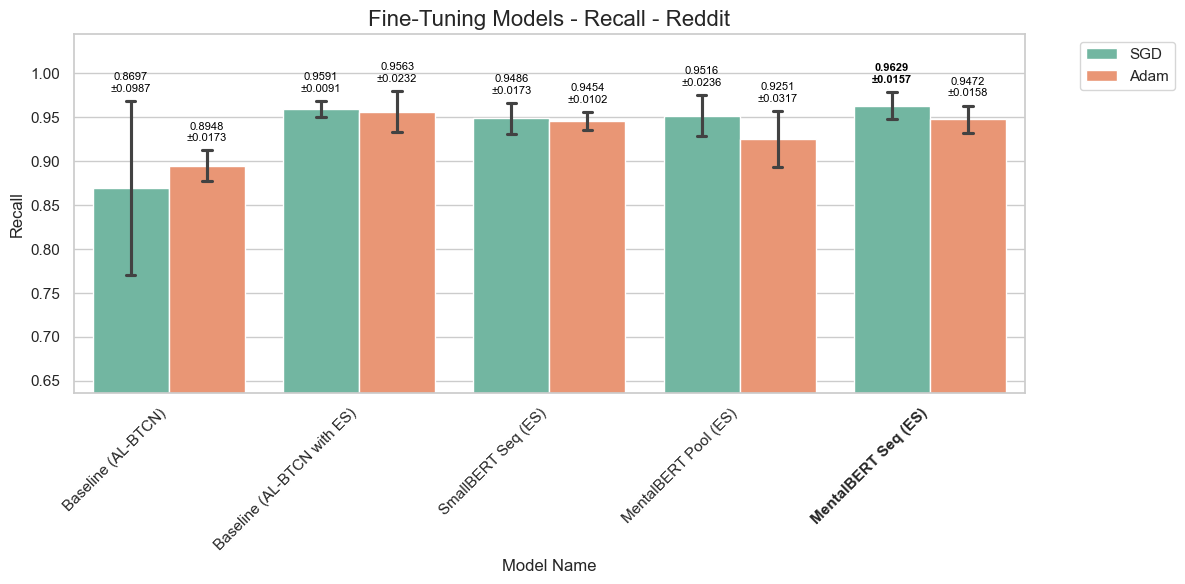

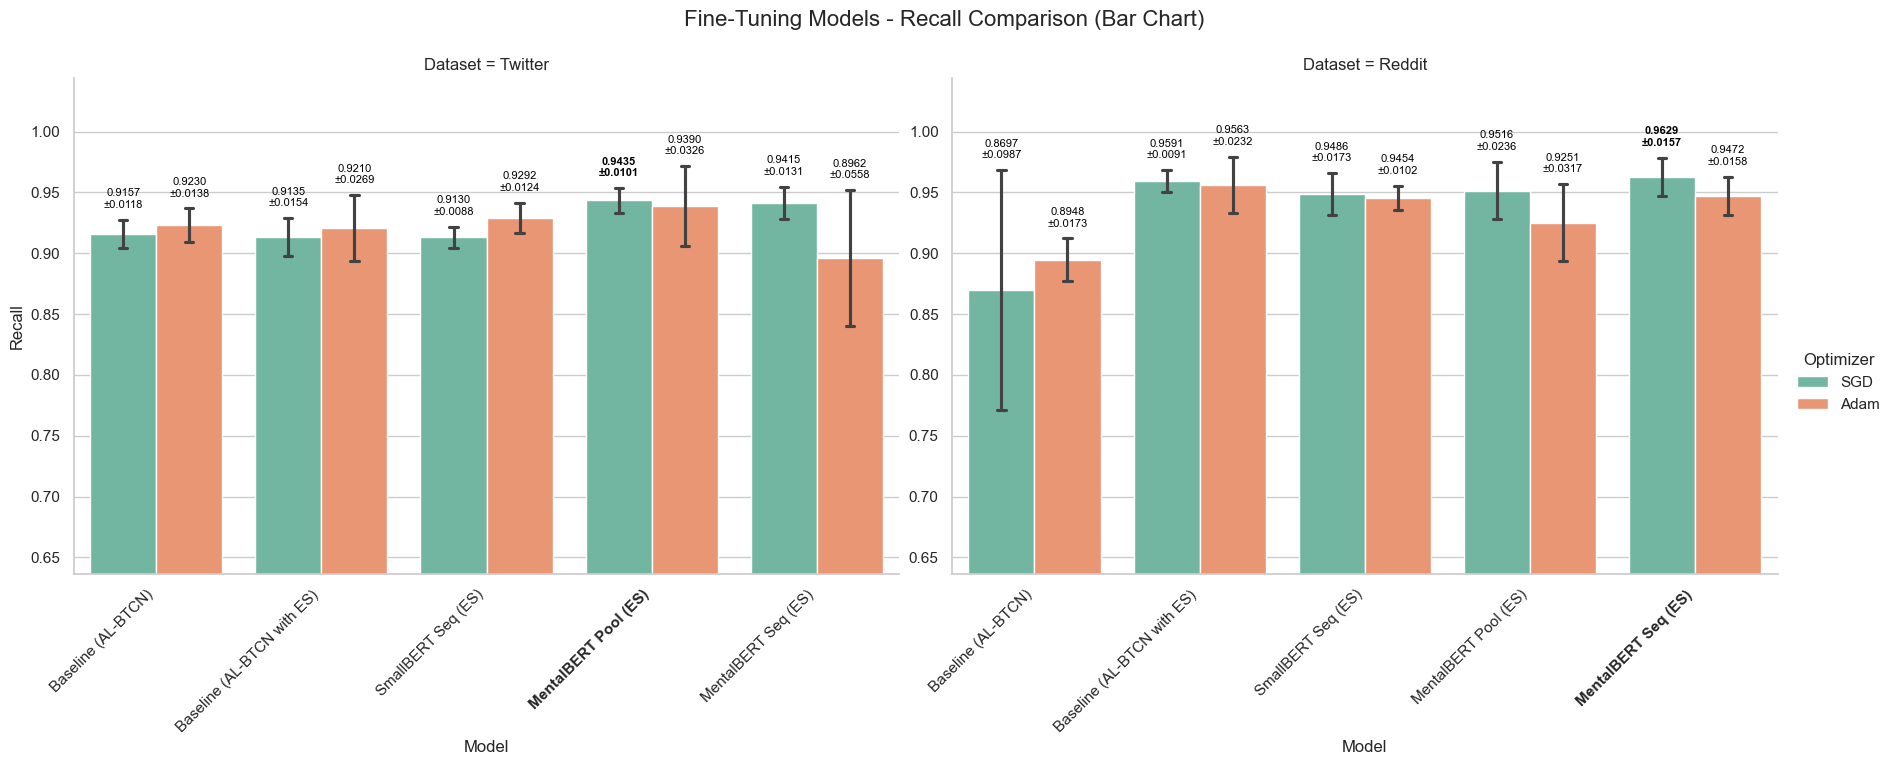

Group 2: Precomputed Models - Recall


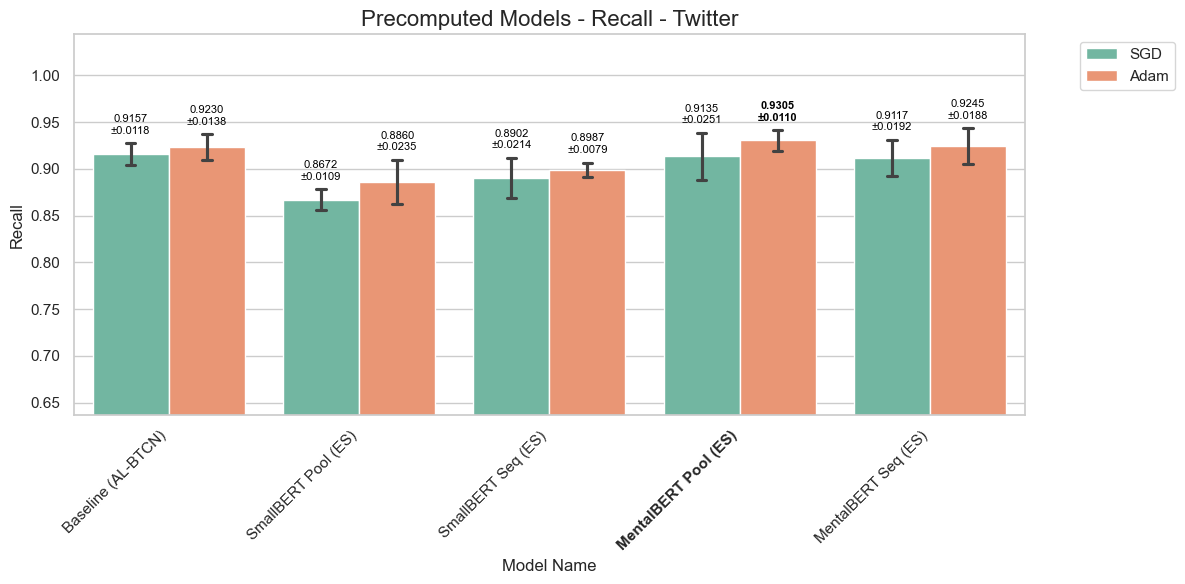

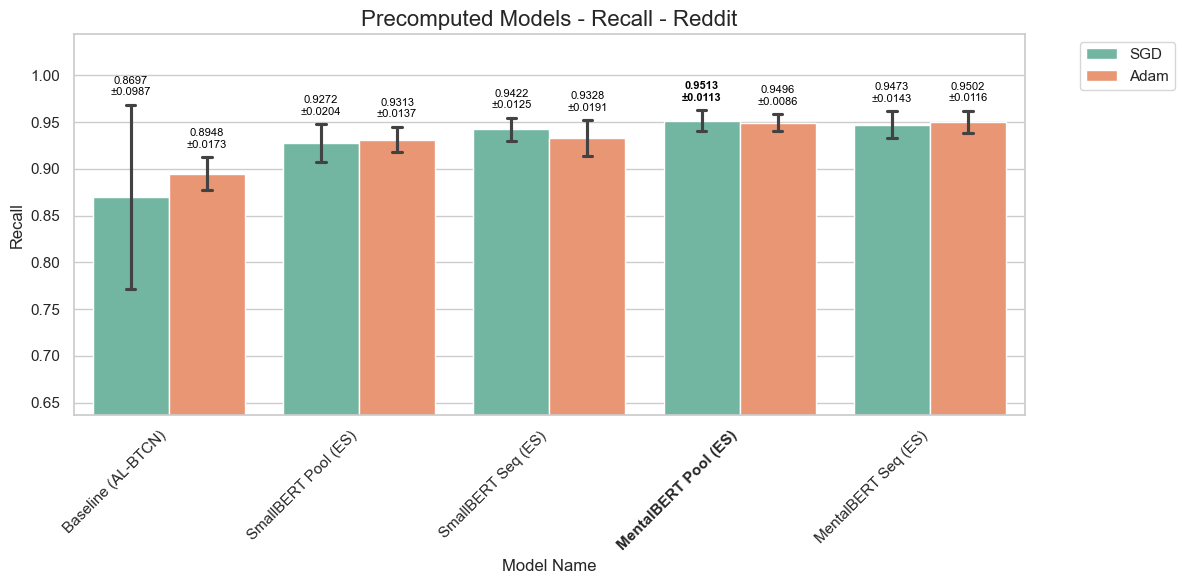

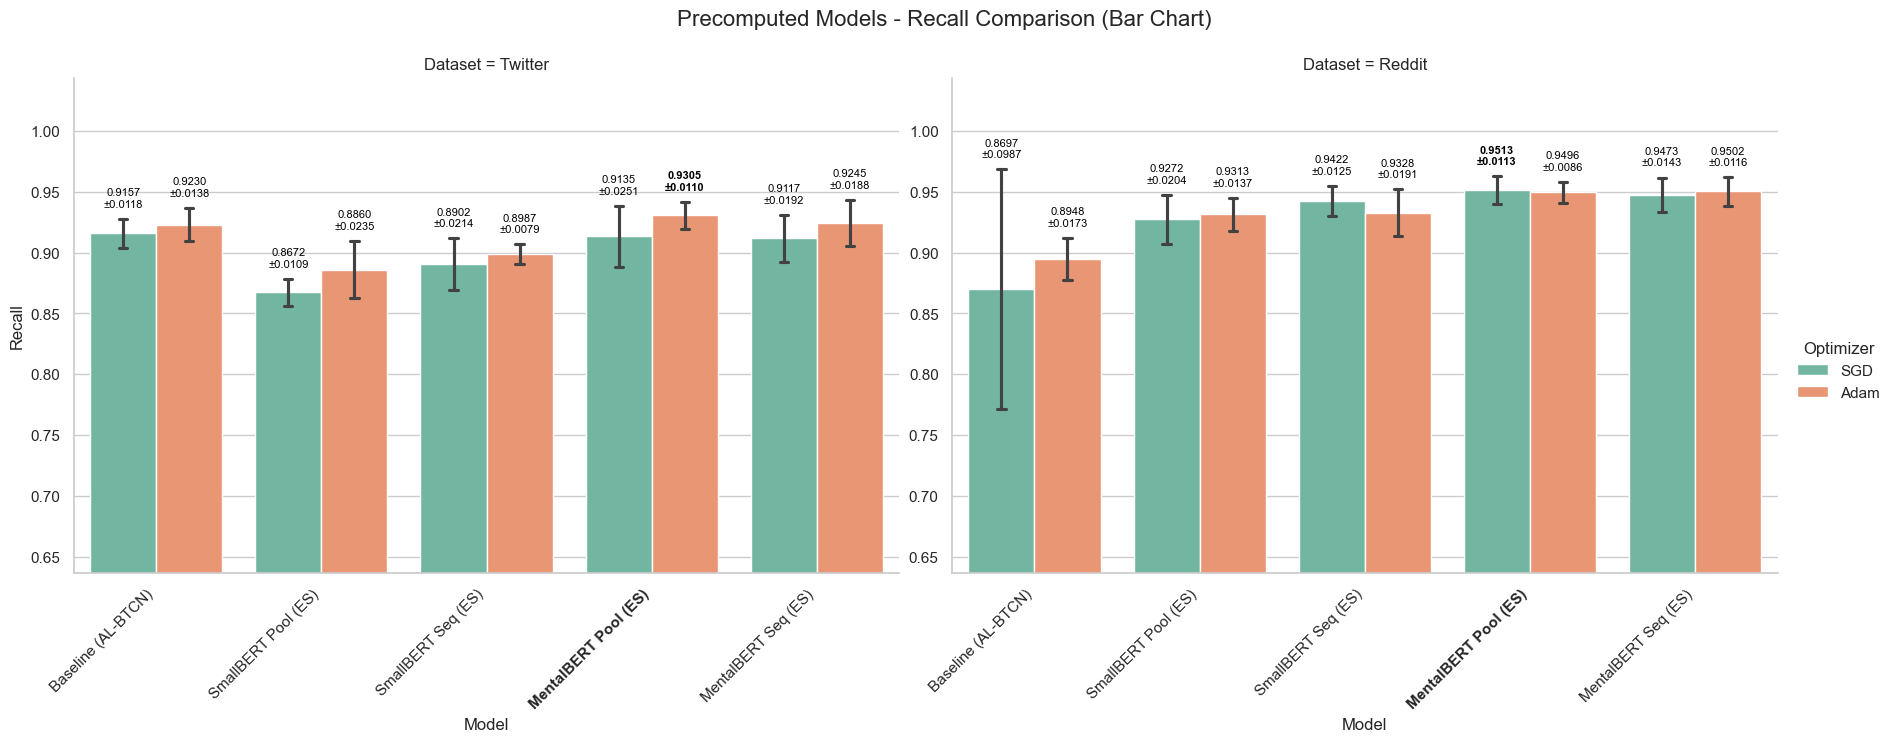

--- F1-Score ---
Group 1: Fine-Tuning Models - F1-Score


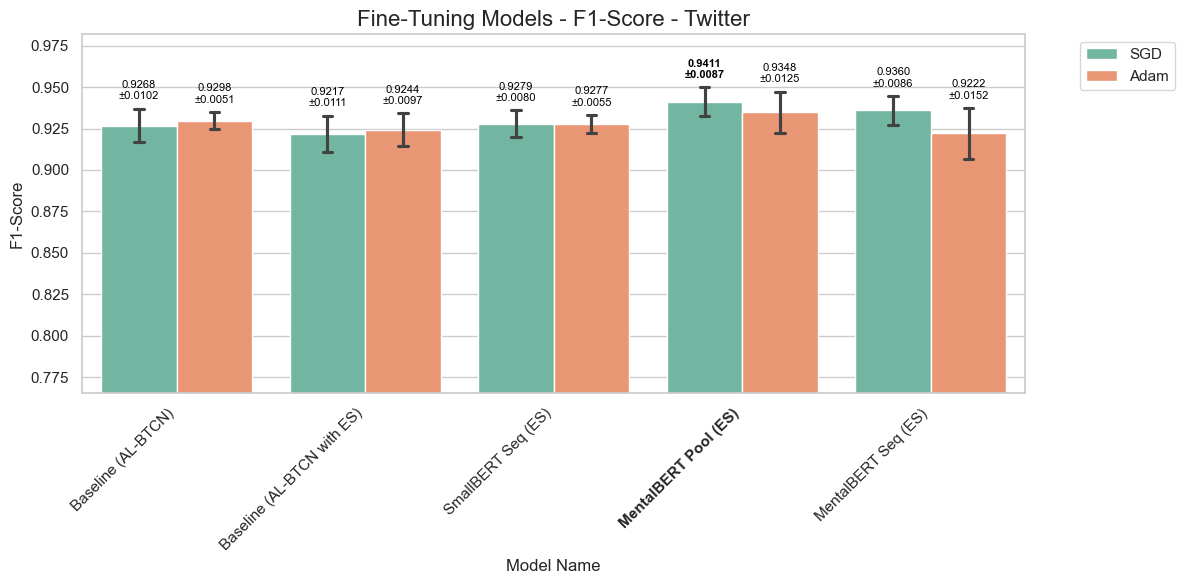

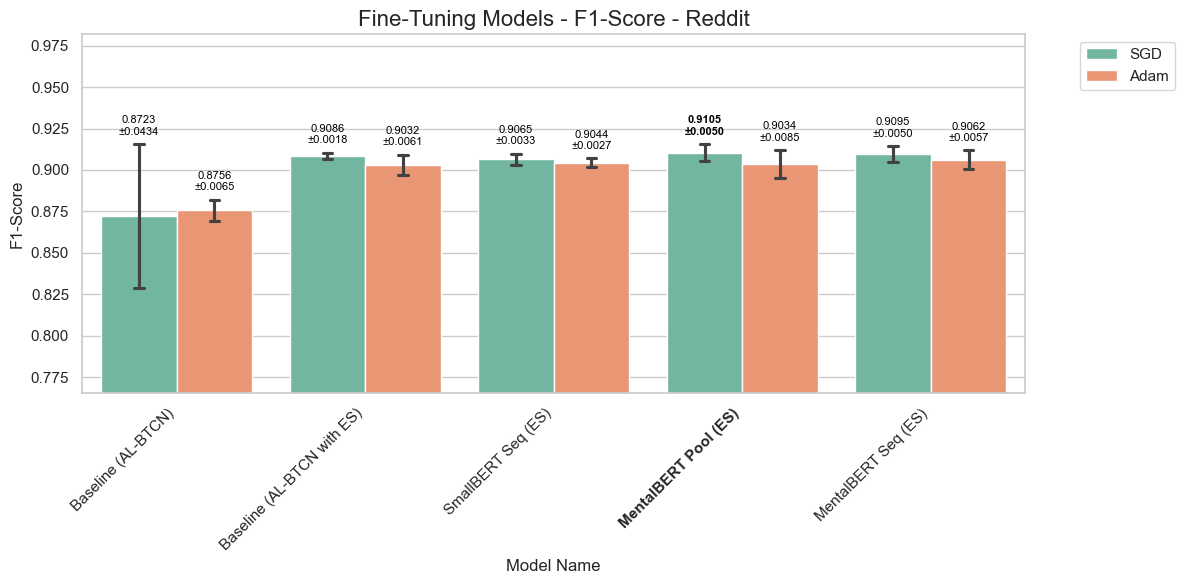

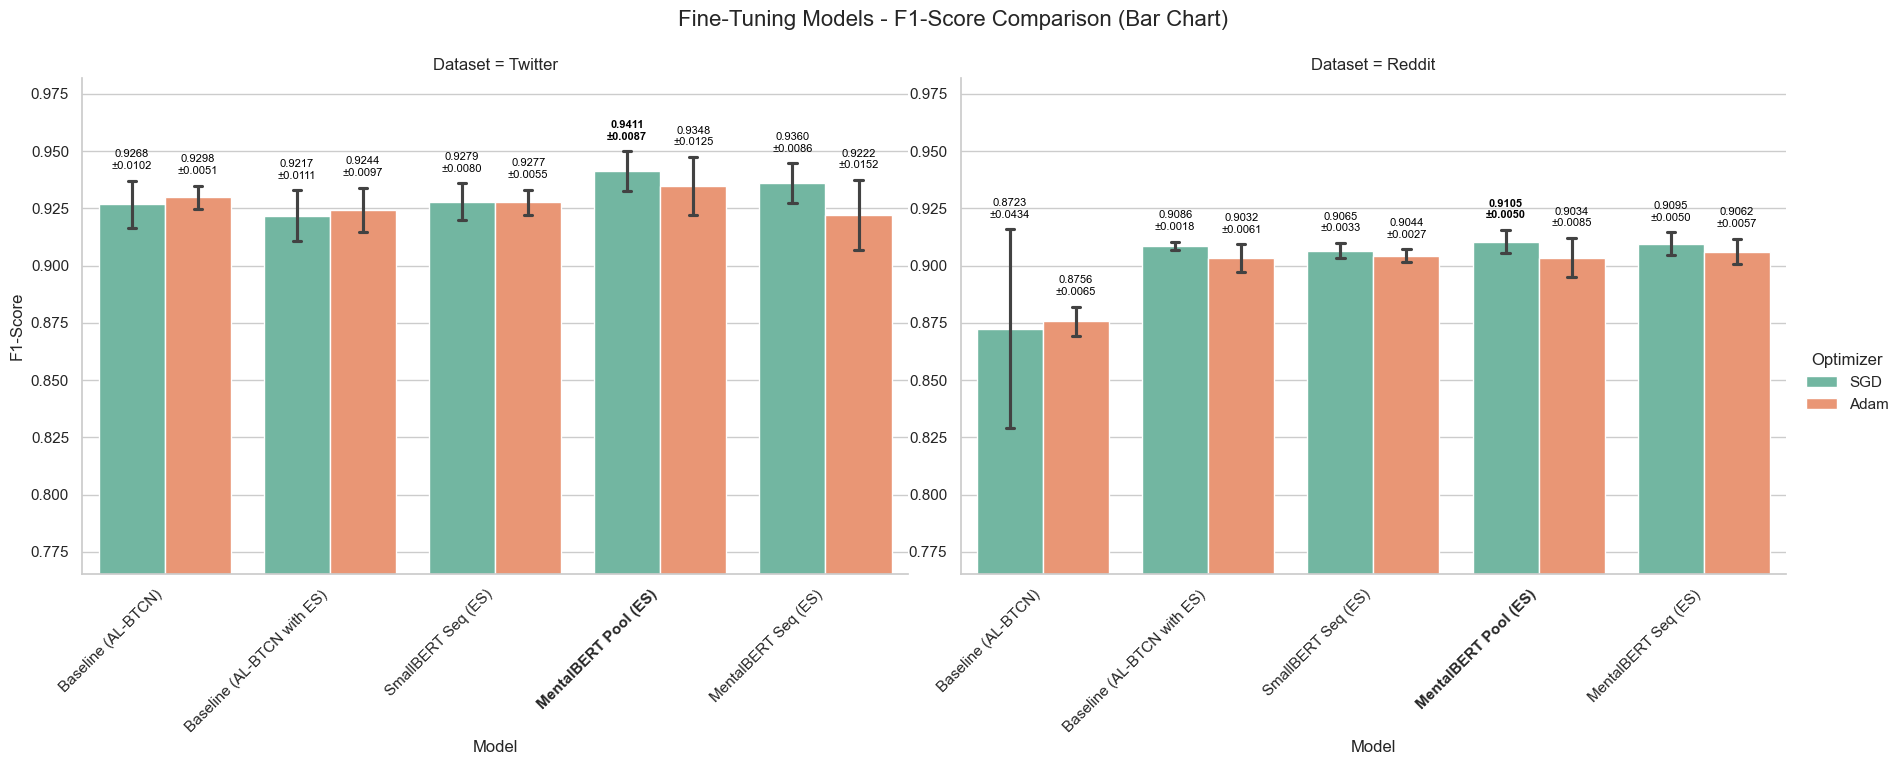

Group 2: Precomputed Models - F1-Score


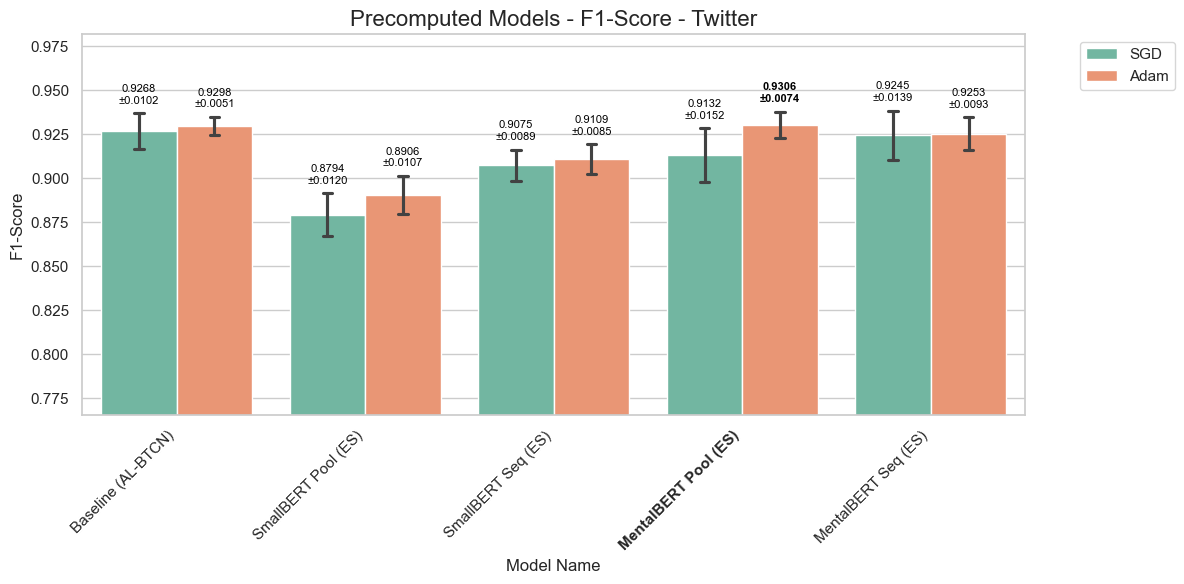

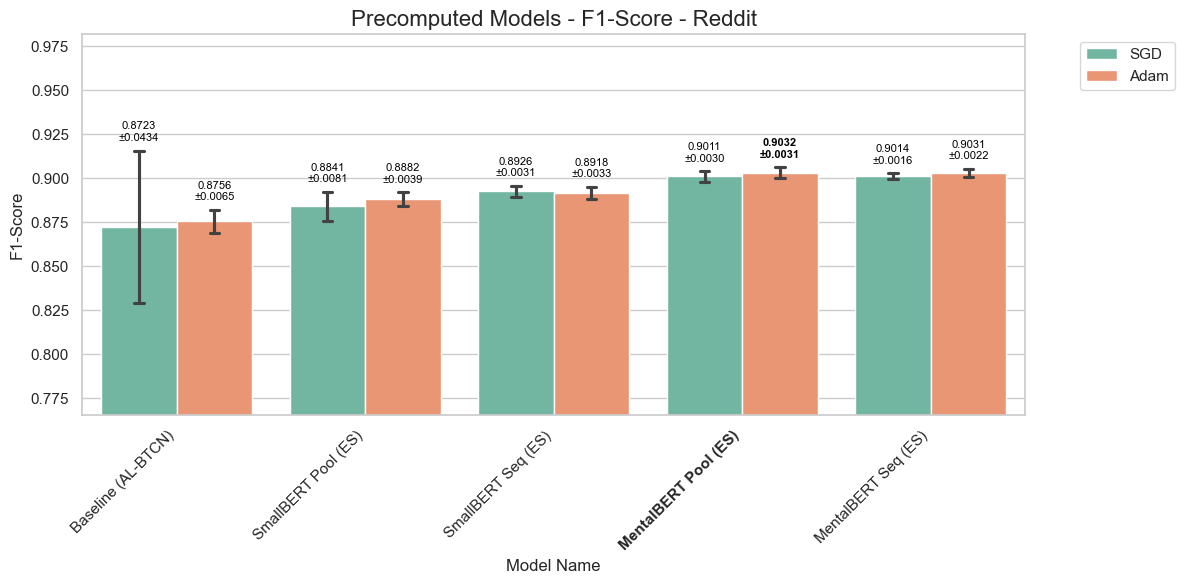

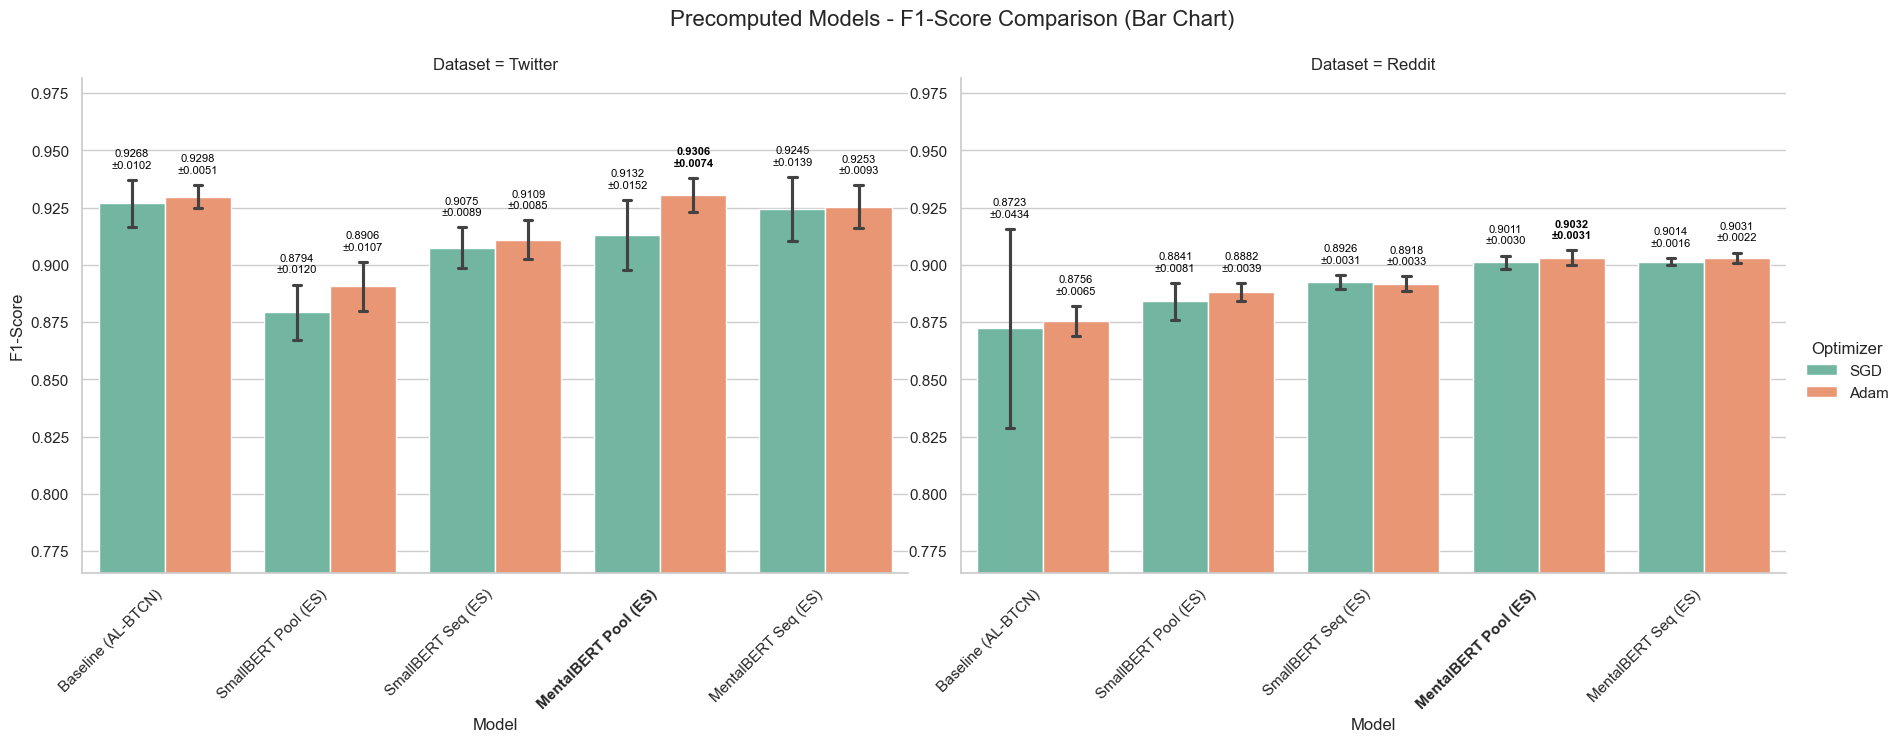

In [5]:
def plot_barchart_dataset(df, dataset_name, group_name, metric='Accuracy', order=None):
    """
    Plots a bar chart for a specific dataset.
    """
    # Determine if higher is better based on metric name
    higher_is_better = 'Time' not in metric

    # Filter for dataset
    data = df[df['Dataset'] == dataset_name]
    
    palette = {
        'Adam': sns.color_palette("Set2")[1],
        'SGD': sns.color_palette("Set2")[0]
    }
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=data,
        x="Model Name",
        y=metric,
        hue="Optimizer",
        hue_order=['SGD', 'Adam'],
        palette=palette,
        order=order,
        errorbar='sd', # Show standard deviation
        capsize=.1
    )
    
    # Adjust y-axis limits to be consistent across all charts
    # Use full_df to get the global min/max for the metric
    y_min = full_df[metric].min()
    y_max = full_df[metric].max()
    y_range = y_max - y_min
    
    lower_ylim = y_min - y_range * 0.2
    
    # Ensure non-negative lower limit for time
    if not higher_is_better:
        lower_ylim = max(0, lower_ylim)
        
    # Always add extra space on top for annotations
    upper_ylim = y_max + y_range * 0.2

    plt.ylim(lower_ylim, upper_ylim)
    
    plt.title(f'{group_name} - {metric} - {dataset_name}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add mean and std annotations
    hue_order = ['SGD', 'Adam']
    
    # Find the best mean value for this dataset
    if higher_is_better:
        best_mean = -float('inf')
    else:
        best_mean = float('inf')
        
    best_model = None
    best_optimizer = None
    
    for model_name in order:
        for optimizer in hue_order:
            subset = data[(data['Model Name'] == model_name) & (data['Optimizer'] == optimizer)]
            if not subset.empty:
                mean_val = subset[metric].mean()
                
                if higher_is_better:
                    if mean_val > best_mean:
                        best_mean = mean_val
                        best_model = model_name
                        best_optimizer = optimizer
                else:
                    if mean_val < best_mean:
                        best_mean = mean_val
                        best_model = model_name
                        best_optimizer = optimizer

    # Iterate through bars to add text
    # Note: ax.patches contains the bars. The order depends on hue and x-axis order.
    # Seaborn plots all bars for the first hue, then all bars for the second hue, etc.
    
    n_models = len(order)
    n_hues = len(hue_order)
    
    visible_range = upper_ylim - lower_ylim
    
    for i, patch in enumerate(ax.patches):
        # Calculate which model and optimizer this patch corresponds to
        # Patches are ordered by hue first, then by x-axis category
        hue_idx = i // n_models
        model_idx = i % n_models
        
        if hue_idx >= n_hues or model_idx >= n_models:
            continue
            
        optimizer = hue_order[hue_idx]
        model_name = order[model_idx]
        
        subset = data[(data['Model Name'] == model_name) & (data['Optimizer'] == optimizer)]
        
        if not subset.empty:
            mean_val = subset[metric].mean()
            std_val = subset[metric].std()
            
            # Get bar position
            x = patch.get_x() + patch.get_width() / 2
            
            # Add text
            text = f"{mean_val:.4f}\n±{std_val:.4f}"
            
            # Determine font weight
            is_best = (model_name == best_model) and (optimizer == best_optimizer)
            font_weight = 'bold' if is_best else 'normal'
            
            # Place text on top of the error bar for ALL metrics
            text_y_pos = mean_val + std_val + (visible_range * 0.02)
            va = 'bottom'
            
            ax.text(
                x, 
                text_y_pos, 
                text, 
                ha='center', 
                va=va, 
                fontsize=8, 
                color='black',
                fontweight=font_weight
            )
            
            # Bold x-axis label if it's the best model
            if is_best:
                # This is tricky because x-labels are shared. 
                # We can bold the label corresponding to the best model.
                xticklabels = ax.get_xticklabels()
                for label in xticklabels:
                    if label.get_text() == best_model:
                        label.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

def plot_combined_barchart(df, group_name, metric='Accuracy', order=None):
    """
    Plots a combined bar chart for both datasets.
    """
    # Determine if higher is better based on metric name
    higher_is_better = 'Time' not in metric

    palette = {
        'Adam': sns.color_palette("Set2")[1],
        'SGD': sns.color_palette("Set2")[0]
    }
    
    g = sns.catplot(
        data=df,
        kind="bar",
        x="Model Name",
        y=metric,
        hue="Optimizer",
        hue_order=['SGD', 'Adam'],
        col="Dataset",
        col_order=['Twitter', 'Reddit'],
        palette=palette,
        height=6,
        aspect=1.5,
        order=order,
        errorbar='sd',
        capsize=.1,
        sharey=False
    )
    
    g.fig.suptitle(f'{group_name} - {metric} Comparison (Bar Chart)', y=1.05, fontsize=16)
    g.set_xticklabels(rotation=45, ha='right')
    g.set_axis_labels("Model", metric)
    
    hue_order = ['SGD', 'Adam']
    col_order = ['Twitter', 'Reddit']
    
    # Calculate global limits from full_df
    y_min = full_df[metric].min()
    y_max = full_df[metric].max()
    y_range = y_max - y_min
    
    lower_ylim = y_min - y_range * 0.2
    
    # Ensure non-negative lower limit for time
    if not higher_is_better:
        lower_ylim = max(0, lower_ylim)
        
    # Always add extra space on top for annotations
    upper_ylim = y_max + y_range * 0.2
    
    # Adjust y-axis limits and add annotations for each subplot
    for ax, dataset_name in zip(g.axes.flat, col_order):
        dataset_df = df[df['Dataset'] == dataset_name]
        
        # Find best model for this dataset
        if higher_is_better:
            best_mean = -float('inf')
        else:
            best_mean = float('inf')
            
        best_model = None
        best_optimizer = None
        
        for model_name in order:
            for optimizer in hue_order:
                subset = dataset_df[(dataset_df['Model Name'] == model_name) & (dataset_df['Optimizer'] == optimizer)]
                if not subset.empty:
                    mean_val = subset[metric].mean()
                    
                    if higher_is_better:
                        if mean_val > best_mean:
                            best_mean = mean_val
                            best_model = model_name
                            best_optimizer = optimizer
                    else:
                        if mean_val < best_mean:
                            best_mean = mean_val
                            best_model = model_name
                            best_optimizer = optimizer
        
        # Add annotations
        n_models = len(order)
        n_hues = len(hue_order)
        
        visible_range = upper_ylim - lower_ylim
        
        for i, patch in enumerate(ax.patches):
            hue_idx = i // n_models
            model_idx = i % n_models
            
            if hue_idx >= n_hues or model_idx >= n_models:
                continue
                
            optimizer = hue_order[hue_idx]
            model_name = order[model_idx]
            
            subset = dataset_df[(dataset_df['Model Name'] == model_name) & (dataset_df['Optimizer'] == optimizer)]
            
            if not subset.empty:
                mean_val = subset[metric].mean()
                std_val = subset[metric].std()
                
                x = patch.get_x() + patch.get_width() / 2
                
                text = f"{mean_val:.4f}\n±{std_val:.4f}"
                
                is_best = (model_name == best_model) and (optimizer == best_optimizer)
                font_weight = 'bold' if is_best else 'normal'
                
                # Place text on top of the error bar for ALL metrics
                text_y_pos = mean_val + std_val + (visible_range * 0.02)
                va = 'bottom'
                
                ax.text(
                    x, 
                    text_y_pos, 
                    text, 
                    ha='center', 
                    va=va, 
                    fontsize=8, 
                    color='black',
                    fontweight=font_weight
                )
                
                if is_best:
                    xticklabels = ax.get_xticklabels()
                    for label in xticklabels:
                        if label.get_text() == best_model:
                            label.set_fontweight('bold')
                            
        ax.set_ylim(lower_ylim, upper_ylim)
        
    plt.show()

# Plot Bar Charts for all metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics_to_plot:
    print(f"--- {metric} ---")
    # Plot Bar Charts for Group 1
    print(f"Group 1: Fine-Tuning Models - {metric}")
    plot_barchart_dataset(df_group1, 'Twitter', "Fine-Tuning Models", metric, order=group1_order)
    plot_barchart_dataset(df_group1, 'Reddit', "Fine-Tuning Models", metric, order=group1_order)
    plot_combined_barchart(df_group1, "Fine-Tuning Models", metric, order=group1_order)

    # Plot Bar Charts for Group 2
    print(f"Group 2: Precomputed Models - {metric}")
    plot_barchart_dataset(df_group2, 'Twitter', "Precomputed Models", metric, order=group2_order)
    plot_barchart_dataset(df_group2, 'Reddit', "Precomputed Models", metric, order=group2_order)
    plot_combined_barchart(df_group2, "Precomputed Models", metric, order=group2_order)

In [6]:
# Calculate Adam Optimizer Contribution
def calculate_adam_contribution(df):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    # Calculate mean for each group
    grouped = df.groupby(['Model Group', 'Dataset', 'Model Name', 'Optimizer'])[metrics].mean().reset_index()
    
    # Pivot to get Adam and SGD in separate columns
    pivoted = grouped.pivot(index=['Model Group', 'Dataset', 'Model Name'], columns='Optimizer', values=metrics)
    
    # Calculate Gain (Adam - SGD)
    contribution = pd.DataFrame(index=pivoted.index)
    for metric in metrics:
        contribution[f'{metric} Gain'] = pivoted[metric]['Adam'] - pivoted[metric]['SGD']
        
    return contribution

adam_contribution = calculate_adam_contribution(full_df)
print("Contribution of Adam Optimizer (Mean Metric Difference: Adam - SGD):")
display(adam_contribution.round(4))


Contribution of Adam Optimizer (Mean Metric Difference: Adam - SGD):


Accuracy Gain  Precision Gain  \
Model Group Dataset Model Name                                                  
Fine-Tuning Reddit  Baseline (AL-BTCN with ES)        -0.0064         -0.0068   
                    Baseline (AL-BTCN)                -0.0026         -0.0253   
                    MentalBERT Pool (ES)              -0.0055          0.0100   
                    MentalBERT Seq (ES)               -0.0023          0.0065   
                    SmallBERT Seq (ES)                -0.0022         -0.0016   
            Twitter Baseline (AL-BTCN with ES)         0.0020         -0.0012   
                    Baseline (AL-BTCN)                 0.0024         -0.0017   
                    MentalBERT Pool (ES)              -0.0058         -0.0064   
                    MentalBERT Seq (ES)               -0.0094          0.0228   
                    SmallBERT Seq (ES)                -0.0012         -0.0172   
Precomputed Reddit  Baseline (AL-BTCN)                -0.0026         -0.0253   
                    MentalBERT Pool (ES)               0.0028          0.0051   
                    MentalBERT Seq (ES)                0.0018          0.0006   
                    SmallBERT Pool (ES)                0.0044          0.0039   
                    SmallBERT Seq (ES)                 0.0002          0.0063   
            Twitter Baseline (AL-BTCN)                 0.0024         -0.0017   
                    MentalBERT Pool (ES)               0.0156          0.0161   
                    MentalBERT Seq (ES)               -0.0002         -0.0110   
                    SmallBERT Pool (ES)                0.0089          0.0040   
                    SmallBERT Seq (ES)                 0.0024         -0.0024   

                                                Recall Gain  F1-Score Gain  
Model Group Dataset Model Name                                              
Fine-Tuning Reddit  Baseline (AL-BTCN with ES)      -0.0029        -0.0055  
                    Baseline (AL-BTCN)               0.0251         0.0033  
                    MentalBERT Pool (ES)            -0.0265        -0.0071  
                    MentalBERT Seq (ES)             -0.0157        -0.0034  
                    SmallBERT Seq (ES)              -0.0032        -0.0021  
            Twitter Baseline (AL-BTCN with ES)       0.0075         0.0027  
                    Baseline (AL-BTCN)               0.0073         0.0030  
                    MentalBERT Pool (ES)            -0.0045        -0.0064  
                    MentalBERT Seq (ES)             -0.0453        -0.0138  
                    SmallBERT Seq (ES)               0.0163        -0.0002  
Precomputed Reddit  Baseline (AL-BTCN)               0.0251         0.0033  
                    MentalBERT Pool (ES)            -0.0017         0.0021  
                    MentalBERT Seq (ES)              0.0029         0.0017  
                    SmallBERT Pool (ES)              0.0041         0.0041  
                    SmallBERT Seq (ES)              -0.0094        -0.0009  
            Twitter Baseline (AL-BTCN)               0.0073         0.0030  
                    MentalBERT Pool (ES)             0.0170         0.0174  
                    MentalBERT Seq (ES)              0.0127         0.0008  
                    SmallBERT Pool (ES)              0.0188         0.0112  
                    SmallBERT Seq (ES)               0.0085         0.0034

Training Time Comparison
Group 1: Fine-Tuning Models - Training Time


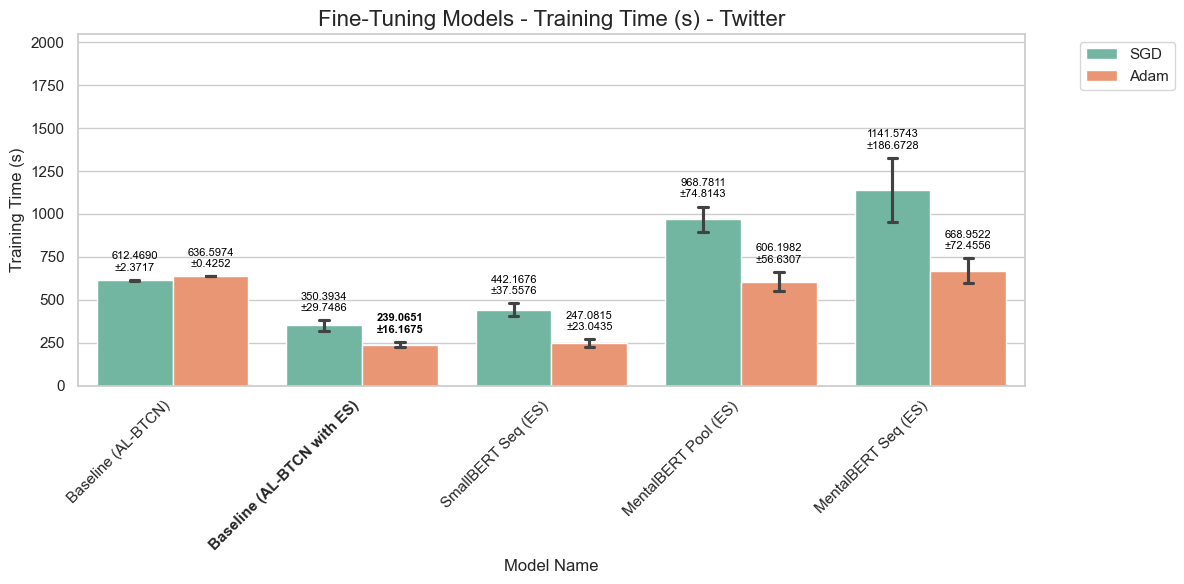

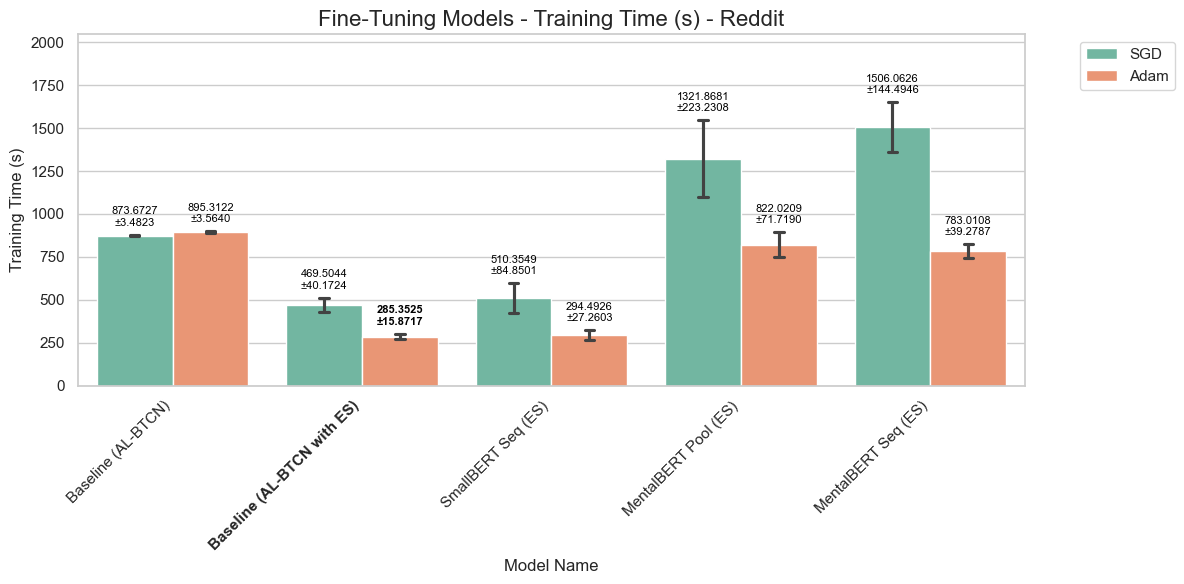

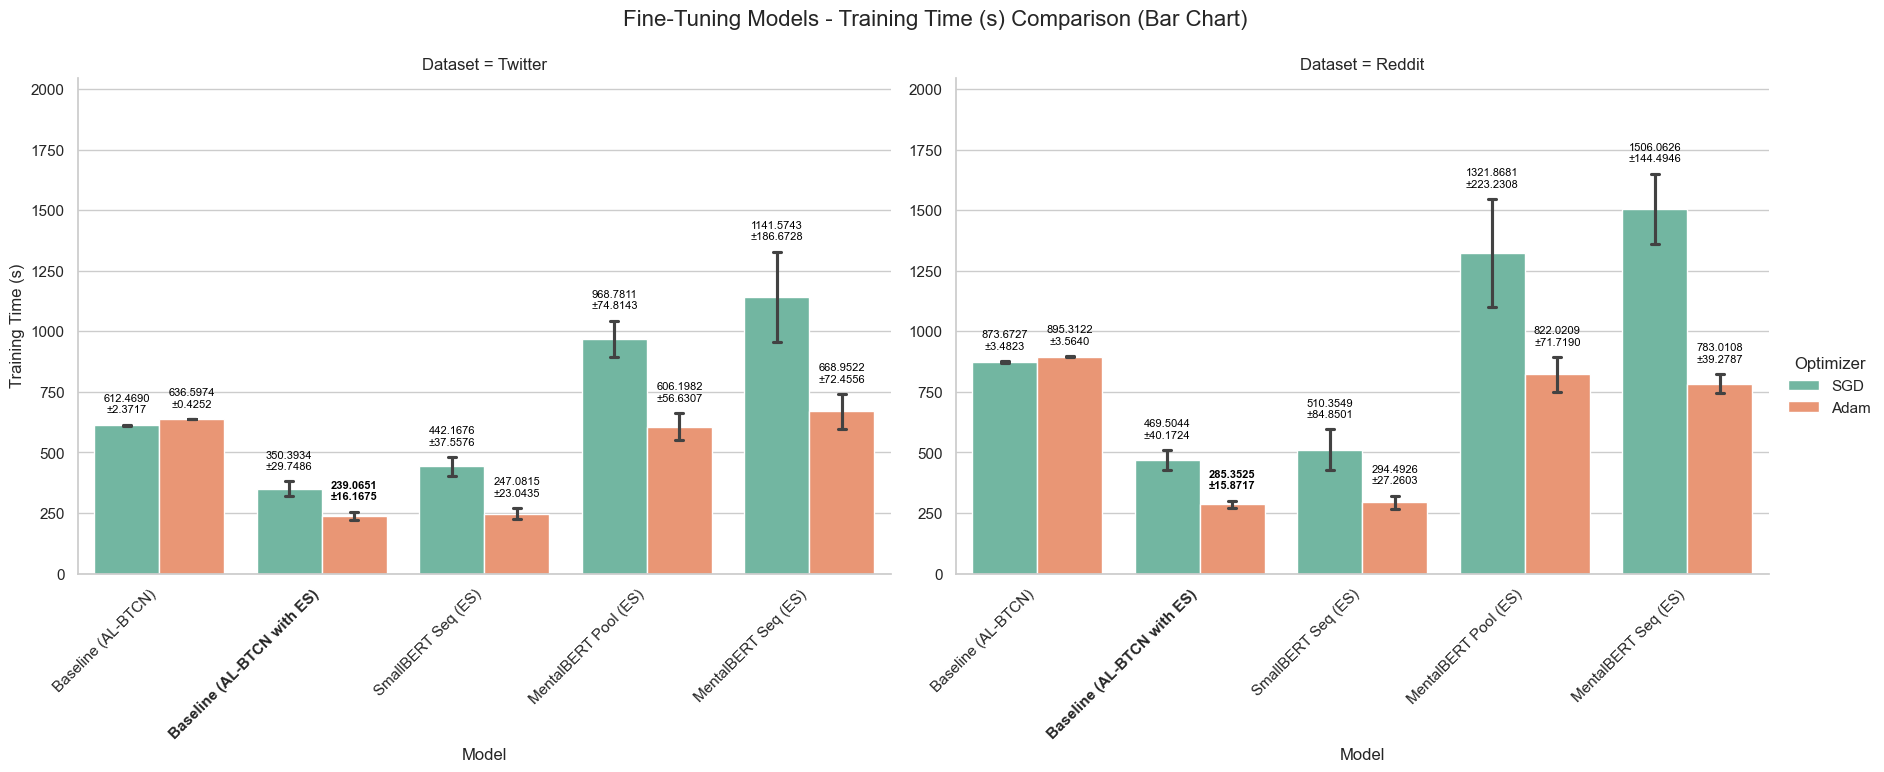

Group 2: Precomputed Models - Training Time


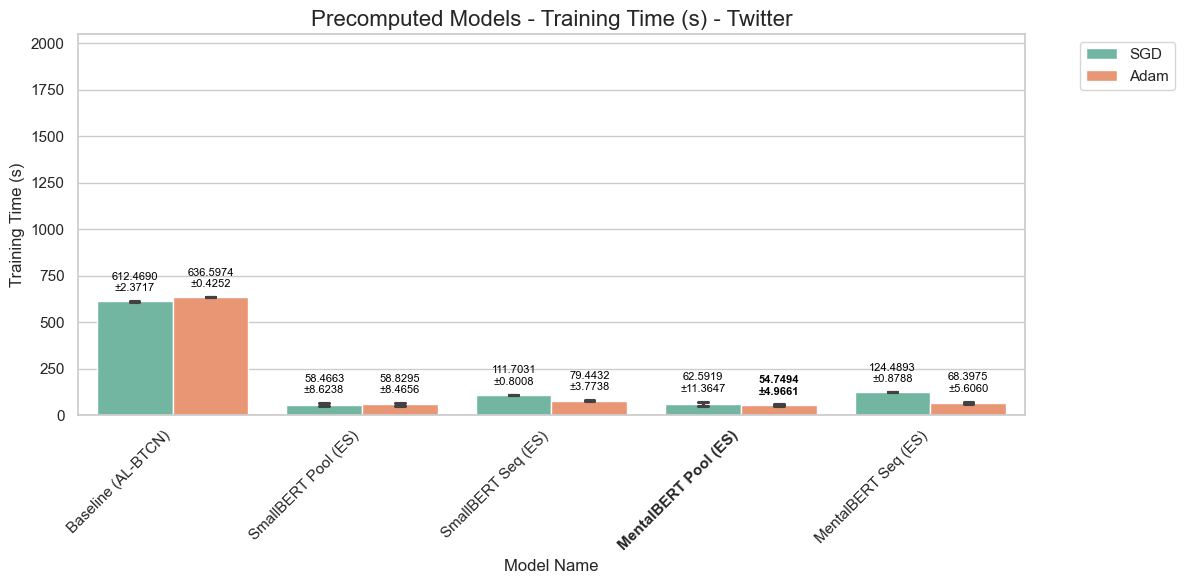

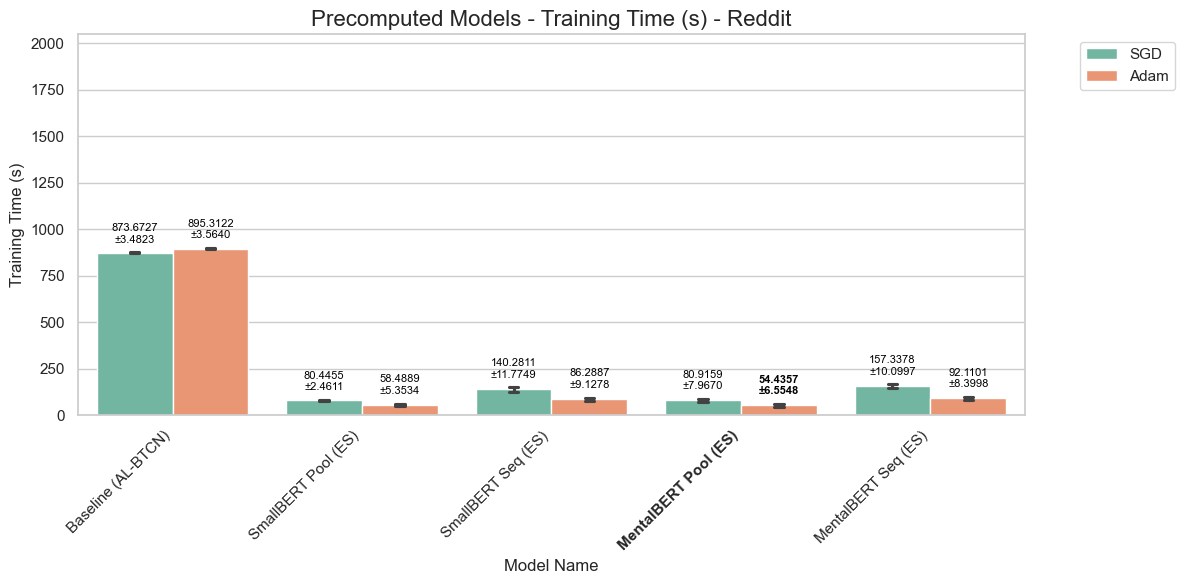

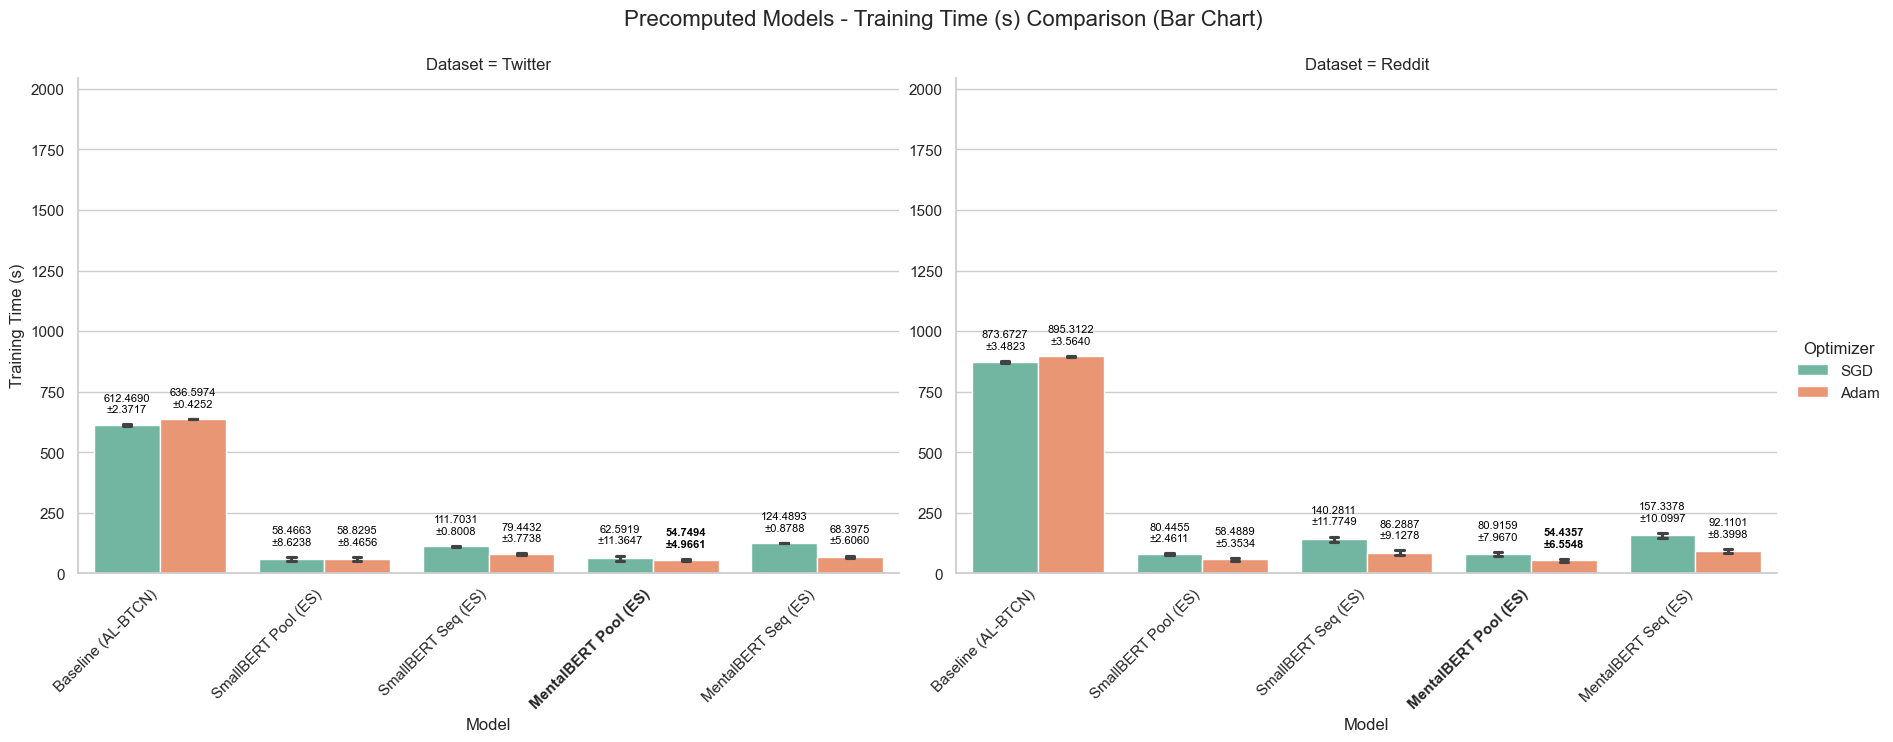

In [7]:
# Training Time Comparison
print("Training Time Comparison")

# Group 1: Fine-Tuning Models
print("Group 1: Fine-Tuning Models - Training Time")
plot_barchart_dataset(df_group1, 'Twitter', "Fine-Tuning Models", 'Training Time (s)', order=group1_order)
plot_barchart_dataset(df_group1, 'Reddit', "Fine-Tuning Models", 'Training Time (s)', order=group1_order)
plot_combined_barchart(df_group1, "Fine-Tuning Models", 'Training Time (s)', order=group1_order)

# Group 2: Precomputed Models
print("Group 2: Precomputed Models - Training Time")
plot_barchart_dataset(df_group2, 'Twitter', "Precomputed Models", 'Training Time (s)', order=group2_order)
plot_barchart_dataset(df_group2, 'Reddit', "Precomputed Models", 'Training Time (s)', order=group2_order)
plot_combined_barchart(df_group2, "Precomputed Models", 'Training Time (s)', order=group2_order)


Performance vs Efficiency Trade-off Analysis

--- Recall vs Efficiency ---


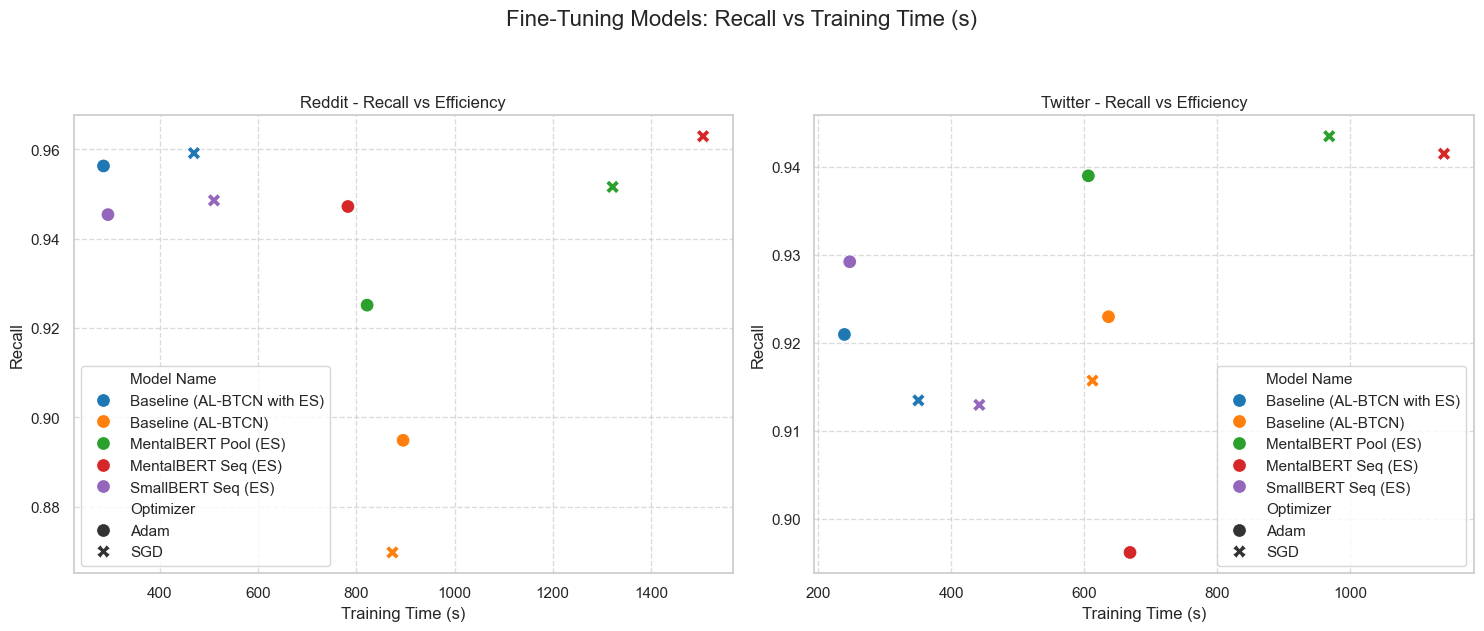

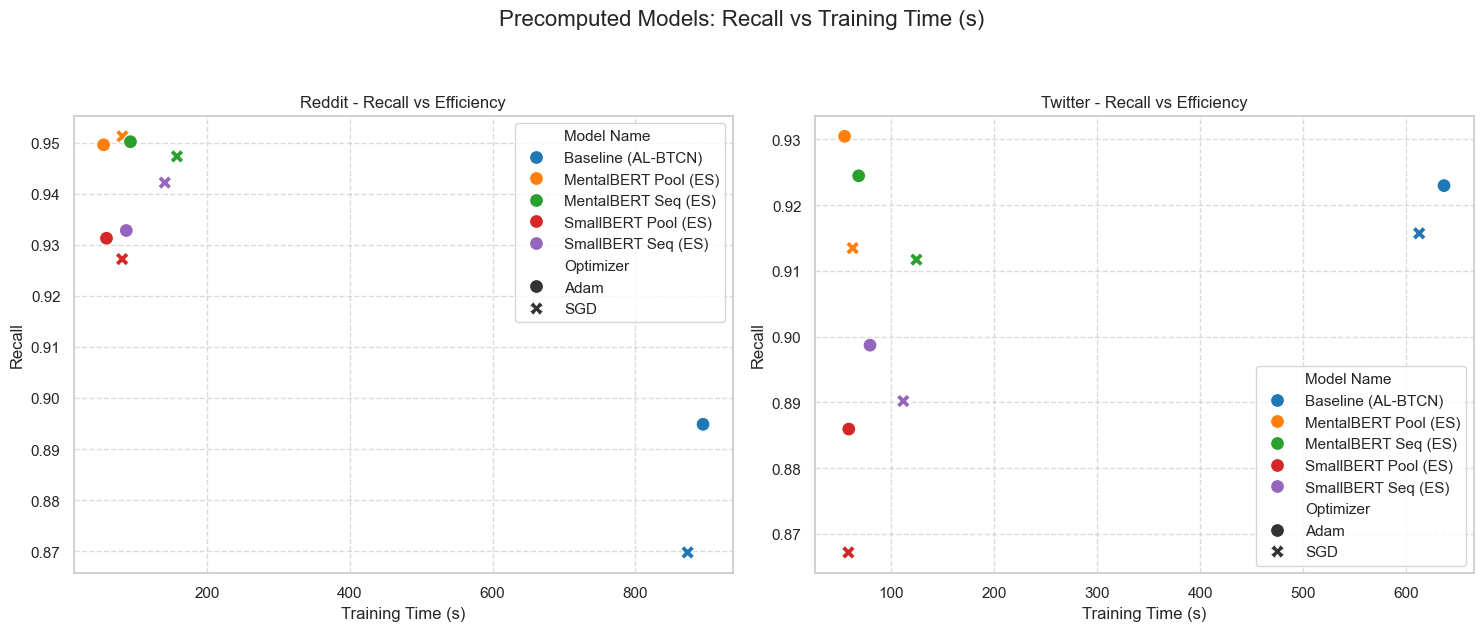


--- F1-Score vs Efficiency ---


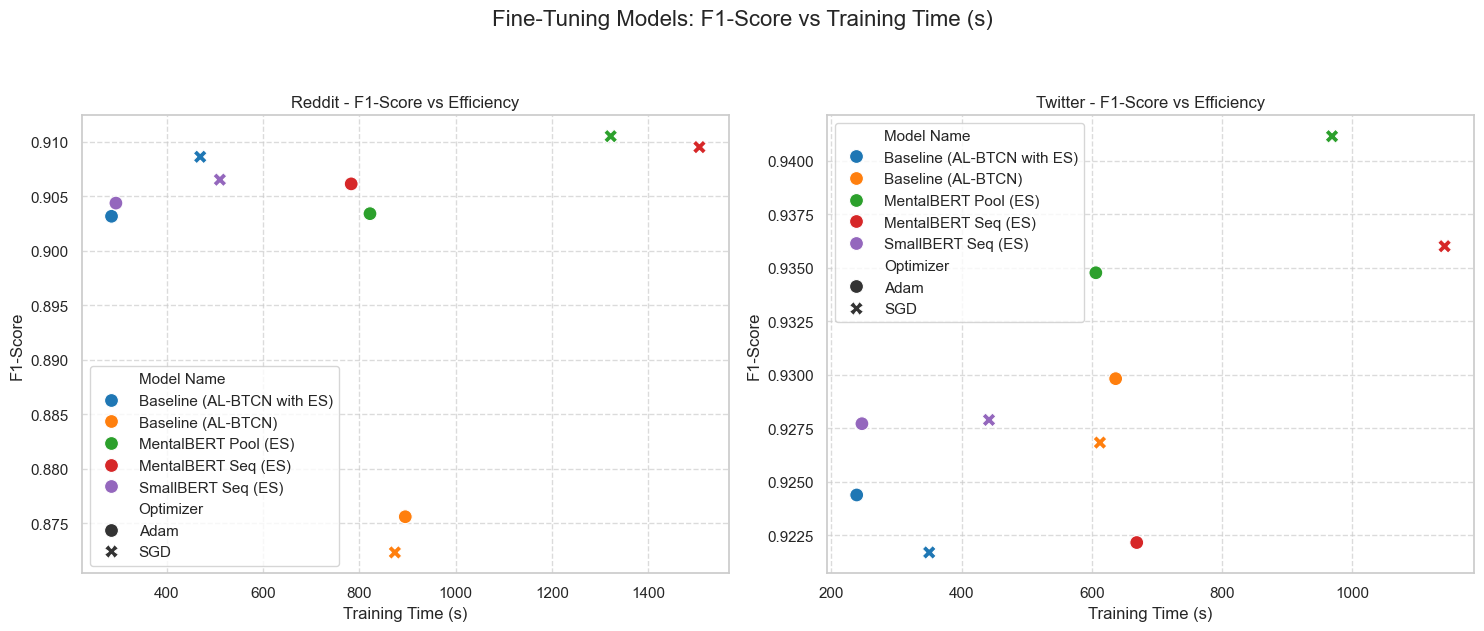

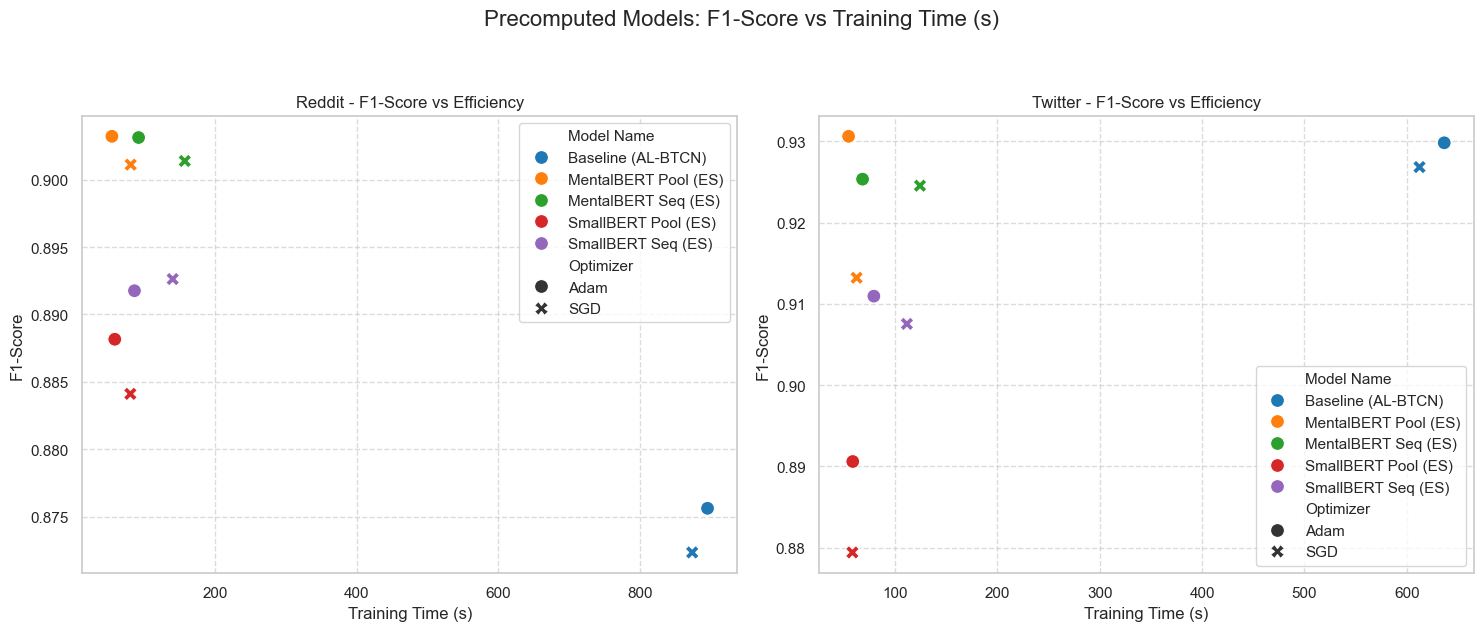

In [8]:
# Performance vs Efficiency Scatter Plot
def plot_efficiency_tradeoff(df, group_name, performance_metric, efficiency_metric='Training Time (s)'):
    """
    Plots a scatter plot of Performance vs Efficiency.
    """
    datasets = df['Dataset'].unique()
    
    palette = sns.color_palette("tab10", n_colors=len(df['Model Name'].unique()))
    
    # Create a figure with subplots for each dataset
    fig, axes = plt.subplots(1, len(datasets), figsize=(15, 6), sharey=False)
    
    if len(datasets) == 1:
        axes = [axes]
        
    for i, dataset in enumerate(datasets):
        ax = axes[i]
        data = df[df['Dataset'] == dataset]
        
        # Calculate mean values for plotting points
        mean_data = data.groupby(['Model Name', 'Optimizer'])[[efficiency_metric, performance_metric]].mean().reset_index()
        
        sns.scatterplot(
            data=mean_data,
            x=efficiency_metric,
            y=performance_metric,
            hue='Model Name',
            style='Optimizer',
            s=100, # Marker size
            ax=ax,
            palette=palette
        )
        
        ax.set_title(f'{dataset} - {performance_metric} vs Efficiency')
        ax.set_xlabel(efficiency_metric)
        ax.set_ylabel(performance_metric)
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Add labels to points
        # for line in range(0, mean_data.shape[0]):
        #     ax.text(
        #         mean_data[efficiency_metric].iloc[line], 
        #         mean_data[performance_metric].iloc[line], 
        #         mean_data['Model Name'].iloc[line], 
        #         horizontalalignment='left', 
        #         size='small', 
        #         color='black', 
        #         weight='semibold'
        #     )

    plt.suptitle(f'{group_name}: {performance_metric} vs {efficiency_metric}', y=1.05, fontsize=16)
    plt.tight_layout()
    plt.show()

print("Performance vs Efficiency Trade-off Analysis")

# Metrics to analyze against Efficiency
metrics_to_analyze = ['Recall', 'F1-Score']

for metric in metrics_to_analyze:
    print(f"\n--- {metric} vs Efficiency ---")
    plot_efficiency_tradeoff(df_group1, "Fine-Tuning Models", metric)
    plot_efficiency_tradeoff(df_group2, "Precomputed Models", metric)